# SEA-Net - data analysis

A thin, read-only notebook. All the figures and tables are built by **`seanet/report.py`** (the same
code `python main.py report` runs), so the plotting lives in one place, not here.

This notebook just calls it and shows the results. It trains nothing; run it any time to see
whatever has finished so far.

**One model = one encoder + one pooling head = one folder.** Every model writes into its own
`results/SEA_NET/<encoder>_<pooling>/`, so the cells below loop over the models that have results.

In [1]:
import os, sys
from pathlib import Path

# Find the repo root (the folder that contains the "seanet" package) and make it importable.
root = Path.cwd()
while root != root.parent and not (root / "seanet" / "__init__.py").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from seanet import report
from seanet import results as R
from IPython.display import Image, display
print("repo root:", root)
print("models with results:", R.discover_models())

repo root: d:\Documents\Intership TSC\Projects\SEA_NET
models with results: ['fcn_conjunctive', 'inceptiontime_conjunctive', 'mstcn_sep_adaptive_classwise', 'mstcn_sep_additive', 'mstcn_sep_classwise_conjunctive', 'mstcn_sep_conjunctive', 'mstcn_sep_softmax_conjunctive', 'resnet_conjunctive']


## 1. Generate everything

This refreshes every model's comparison + summary and draws all the figures - the same call as
`python main.py report`.

In [2]:
out = report.generate_report(verbose=True)

=== SEA-Net report ===

--- fcn_conjunctive ---
  model                   : fcn_conjunctive
  millet85_datasets       : 84
  mean_acc_ours           : 0.8029
  mean_acc_millet         : 0.8433
  acc_win_tie_loss        : 12/17/55
  mean_loss_ours          : 0.5854
  mean_loss_millet        : 1.2321
  loss_win_tie_loss       : 51/1/32
  mean_aopcr_ours         : 0.6864
  mean_aopcr_millet       : 4.5579
  aopcr_win_tie_loss      : 3/0/81
  overall_ucr_datasets    : 124
  overall_mean_acc        : 0.7867
  overall_mean_loss       : 0.6494
  overall_mean_aopcr      : 0.7549
  webtraffic_acc          : 0.566
  params                  : 271131
  model_size_mb           : 3.489

--- inceptiontime_conjunctive ---
  model                   : inceptiontime_conjunctive
  millet85_datasets       : 54
  mean_acc_ours           : 0.7783
  mean_acc_millet         : 0.8318
  acc_win_tie_loss        : 10/7/37
  mean_loss_ours          : 0.6297
  mean_loss_millet        : 1.2362
  loss_win_tie_loss    

## 2. Which model wins?

The cross-model ranking over the **85 datasets MILLET published** - the only ones where a fair
one-to-one comparison exists. MILLET's own means are in the `mean_*_millet` columns, so a model
beats the baseline when its `mean_acc_ours` clears `mean_acc_millet`.

,model,mean_acc_ours,mean_acc_millet,acc_win_tie_loss,mean_loss_ours,mean_loss_millet,mean_aopcr_ours,mean_aopcr_millet
0,resnet_conjunctive,0.8056,0.8433,15/11/58,0.5743,1.2321,0.7005,4.5579
1,fcn_conjunctive,0.8029,0.8433,12/17/55,0.5854,1.2321,0.6864,4.5579
2,mstcn_sep_classwise_conjunctive,0.8020,0.8445,22/12/51,0.5598,1.2241,0.2451,4.5532
3,mstcn_sep_conjunctive,0.8003,0.8445,19/15/51,0.5637,1.2241,0.2031,4.5532
4,mstcn_sep_additive,0.7988,0.8445,16/14/55,0.5674,1.2241,0.2134,4.5532
5,mstcn_sep_softmax_conjunctive,0.7978,0.8406,12/6/35,0.5811,1.2208,0.2256,4.1739
6,mstcn_sep_adaptive_classwise,0.7959,0.8445,16/14/55,0.5739,1.2241,0.3222,4.5532
7,inceptiontime_conjunctive,0.7783,0.8318,10/7/37,0.6297,1.2362,0.0604,4.9375


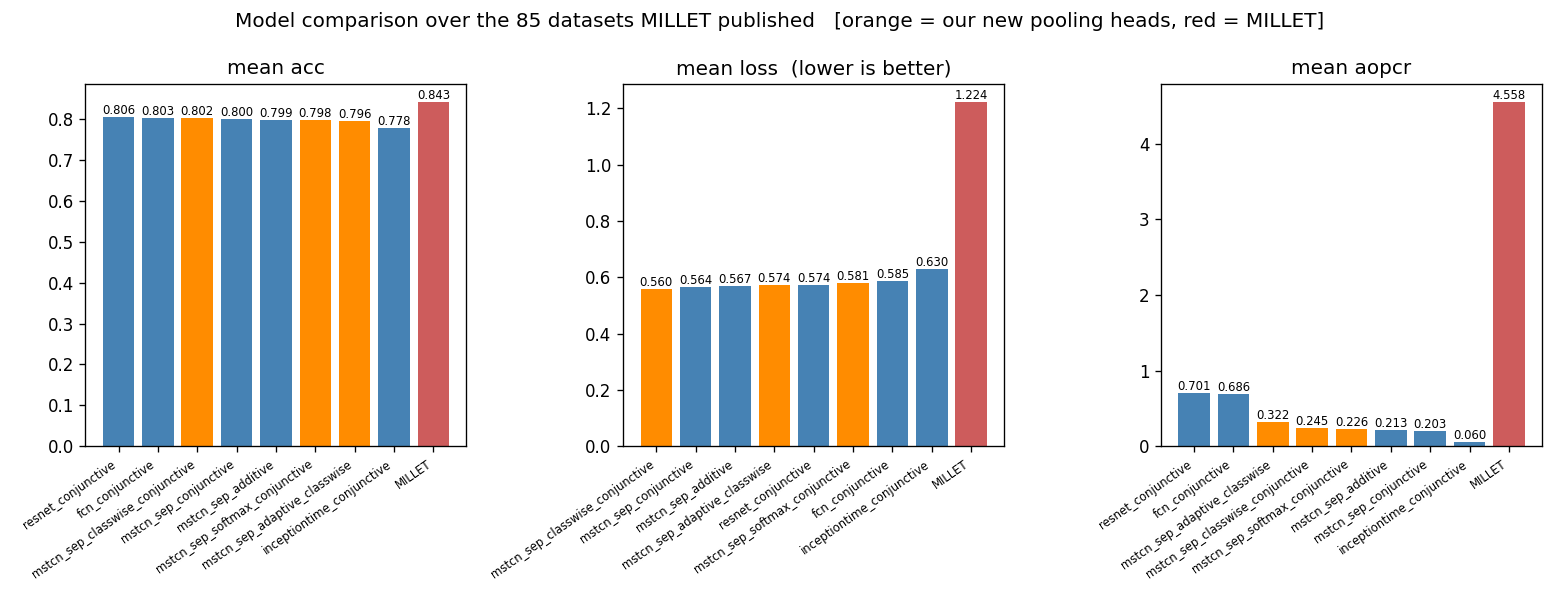

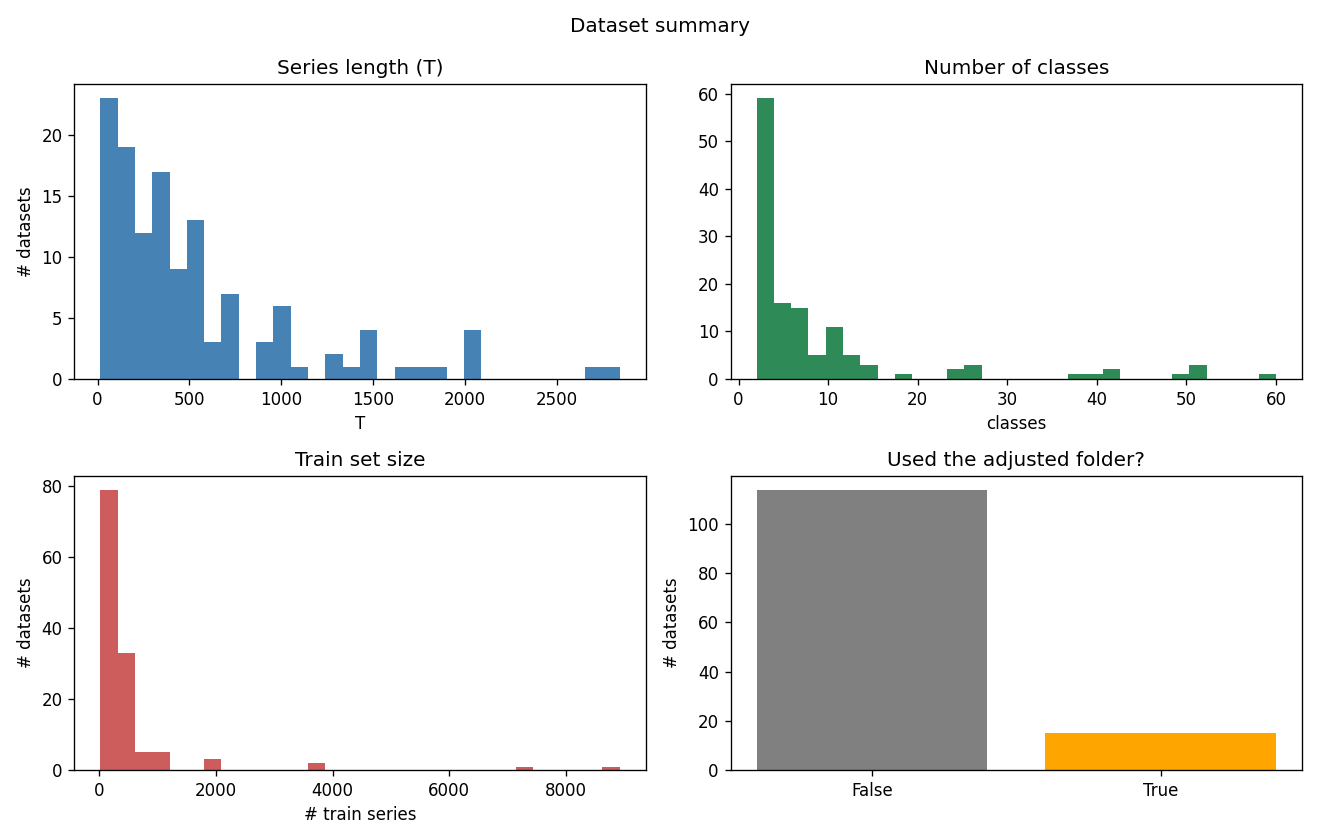

In [3]:
cross = R.compare_models(verbose=False)
display(cross[["model", "mean_acc_ours", "mean_acc_millet", "acc_win_tie_loss",
               "mean_loss_ours", "mean_loss_millet", "mean_aopcr_ours", "mean_aopcr_millet"]]
       if len(cross) else "No model has results yet - run: python main.py train --model seanet")

# our new pooling heads in orange, MILLET's own bar in red
shared = report.SHARED_FIGURES_DIR
for name in ["model_comparison.png", "data_summary.png"]:
    path = os.path.join(shared, name)
    if os.path.exists(path):
        display(Image(filename=path))

## 3. Each model's figures

For every model: its own spread, then the comparison to MILLET. In the accuracy and AOPCR scatters a
point **above** the red y=x line means we win; in the loss scatter **below** the line wins (lower
loss is better). The gold star marks both means.

fcn_conjunctive


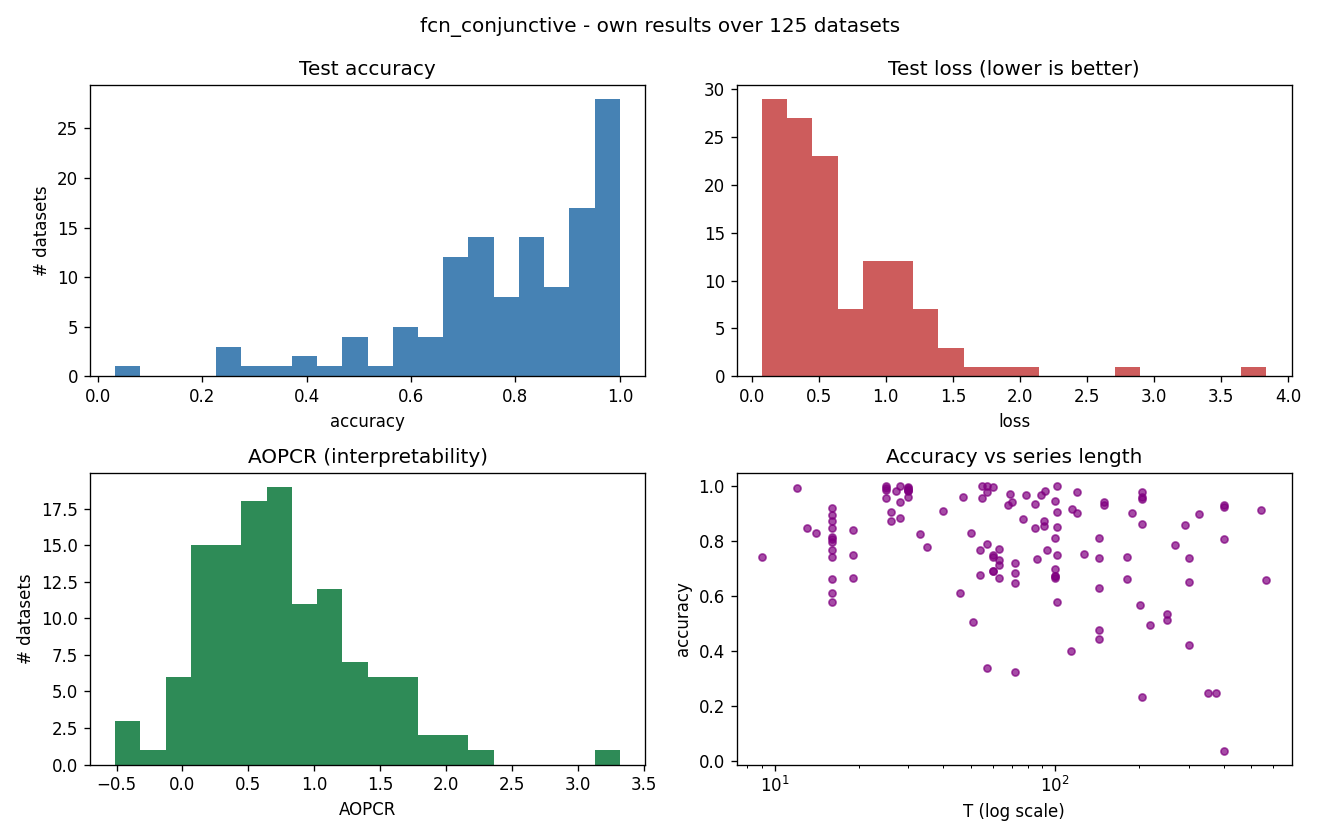

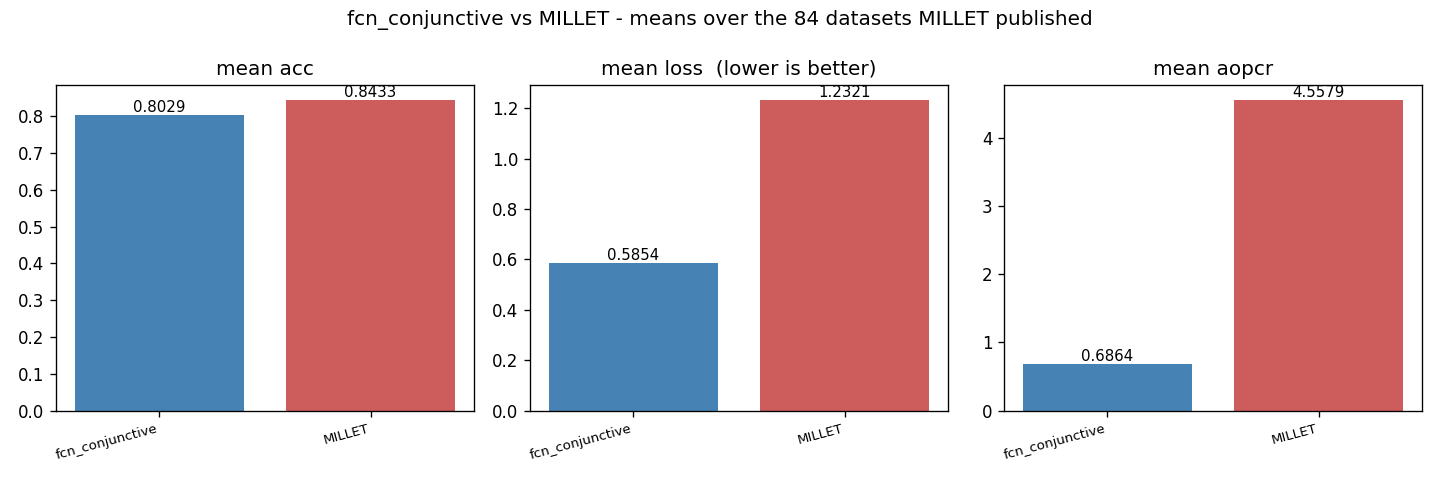

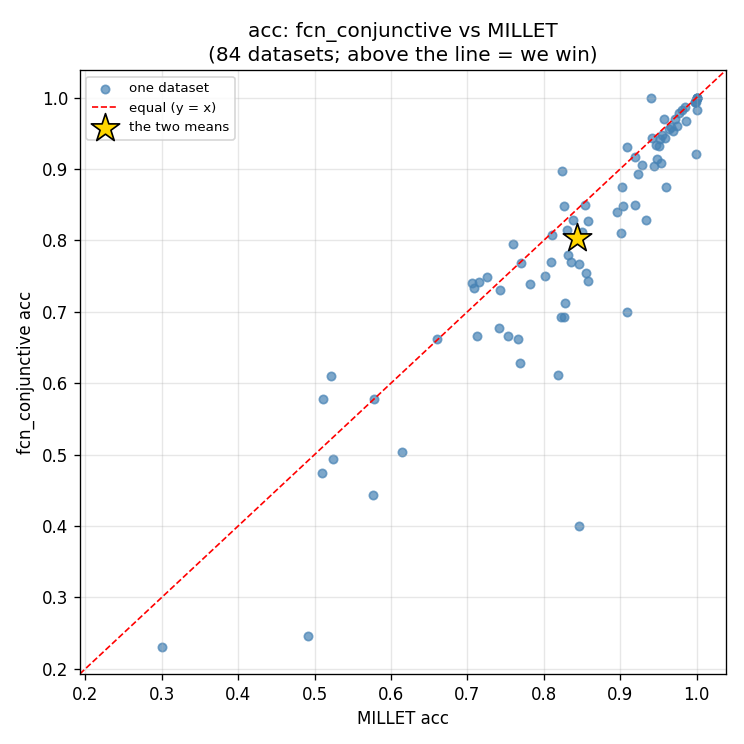

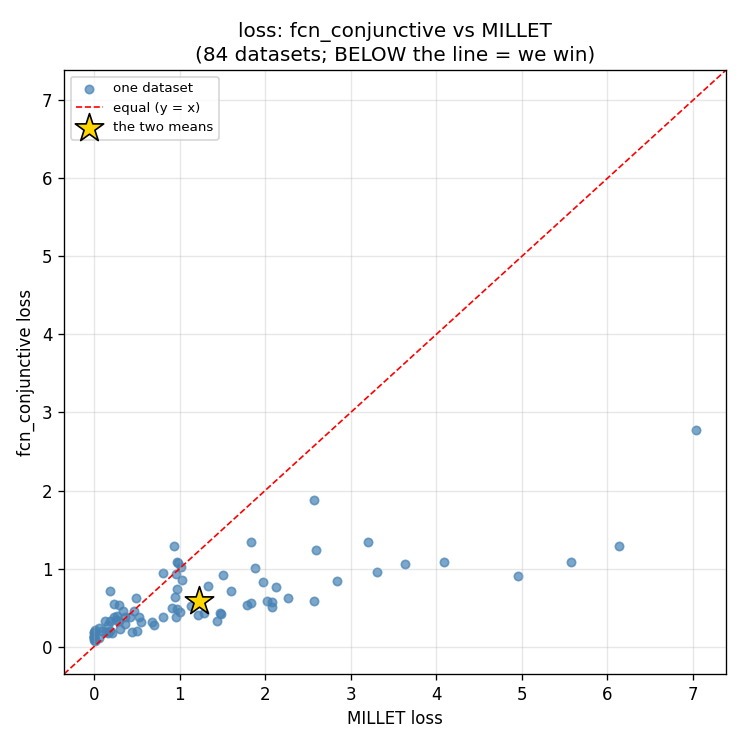

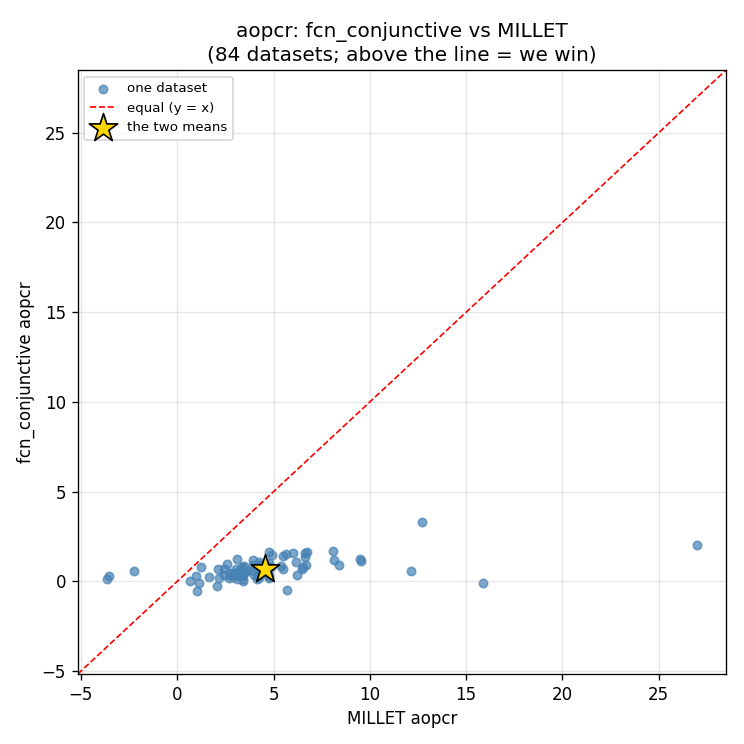

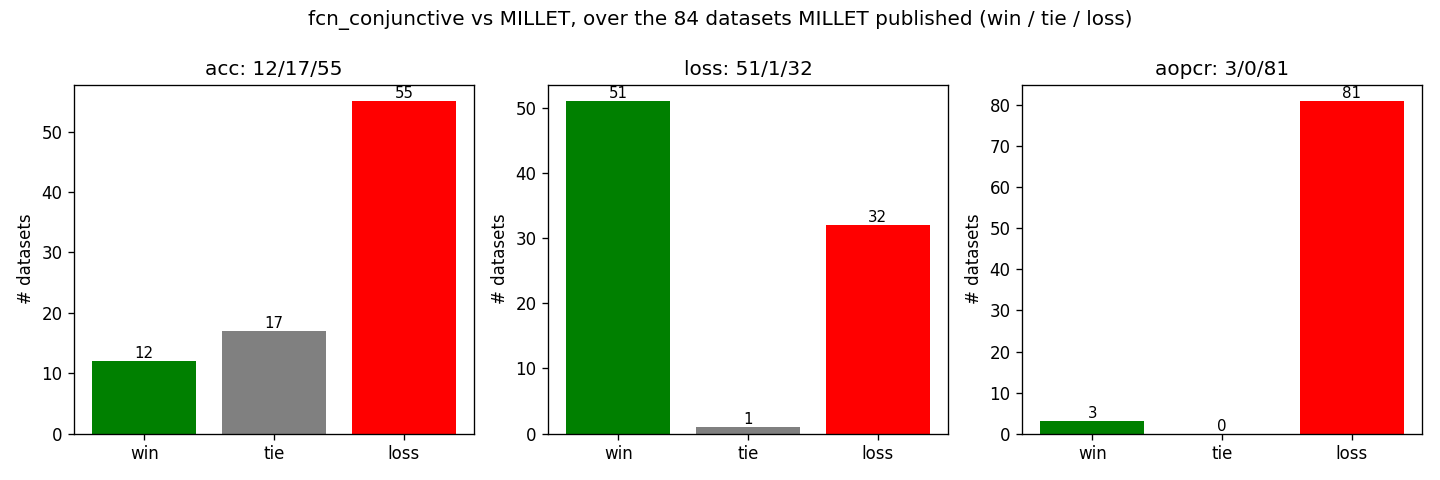

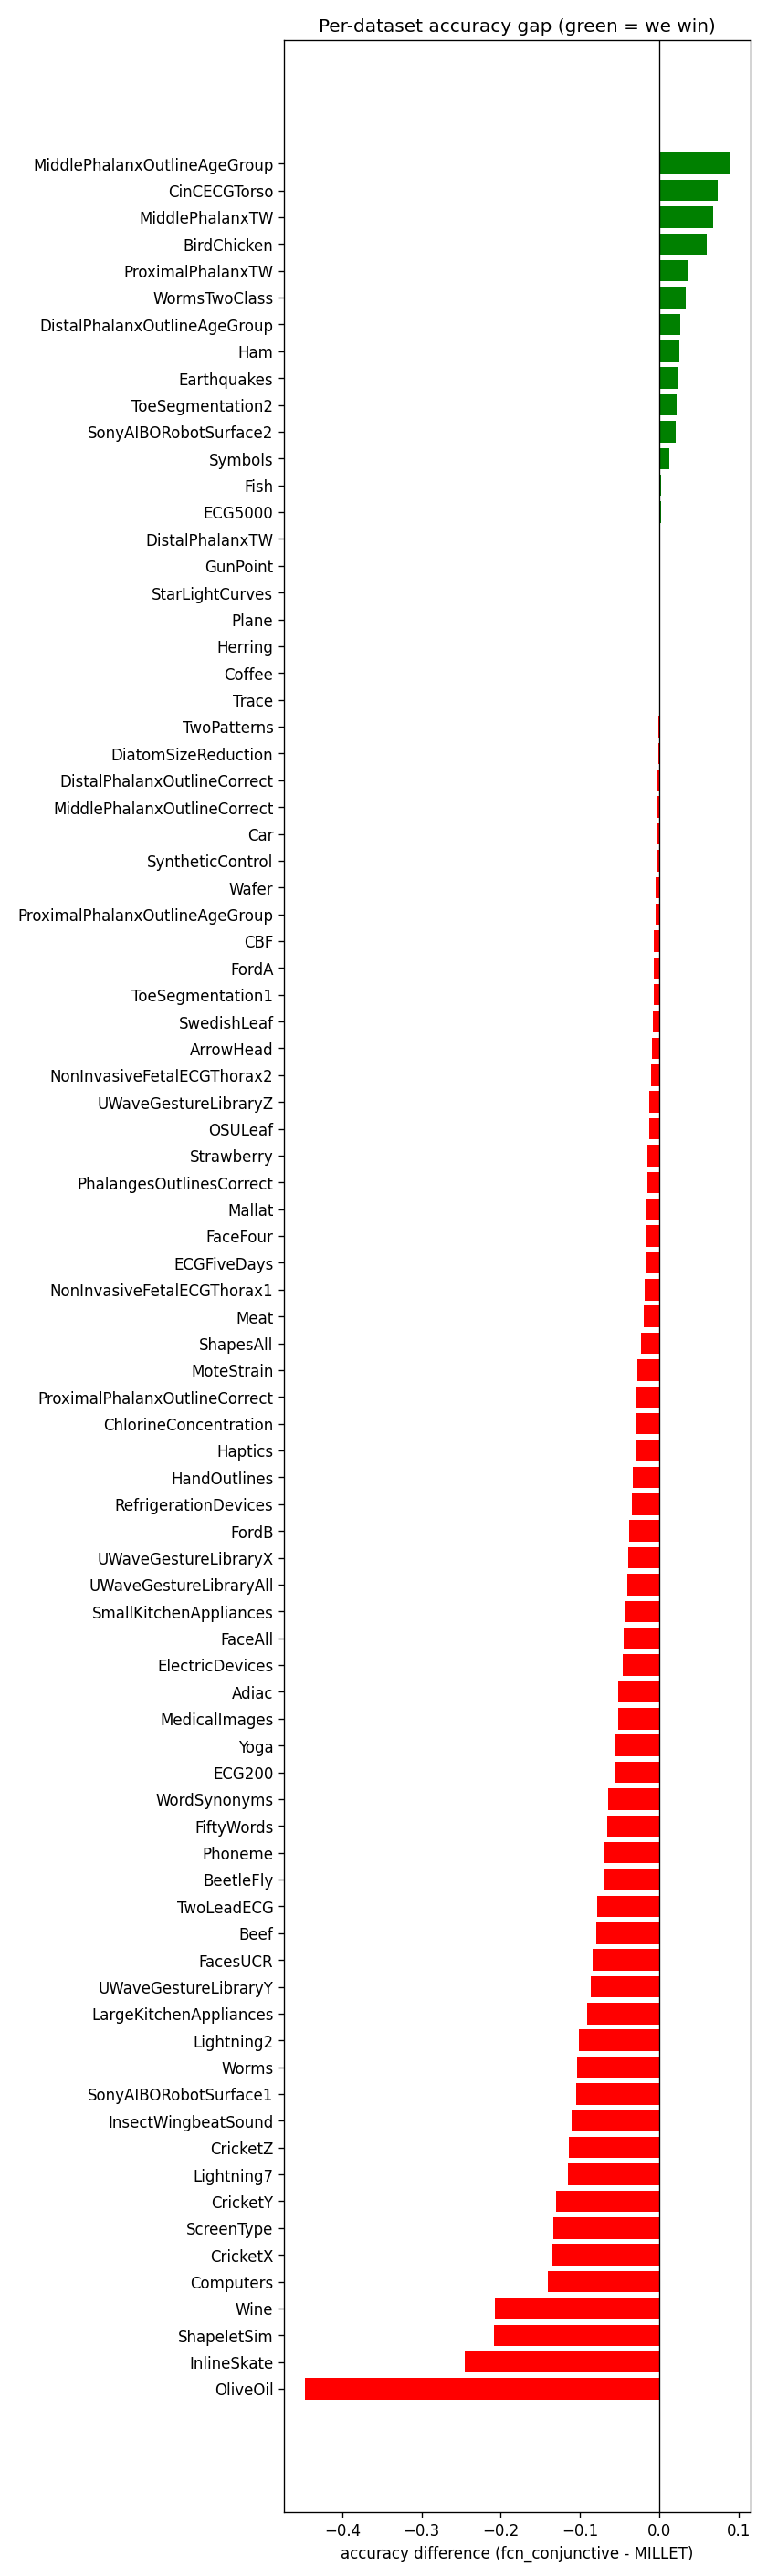

inceptiontime_conjunctive


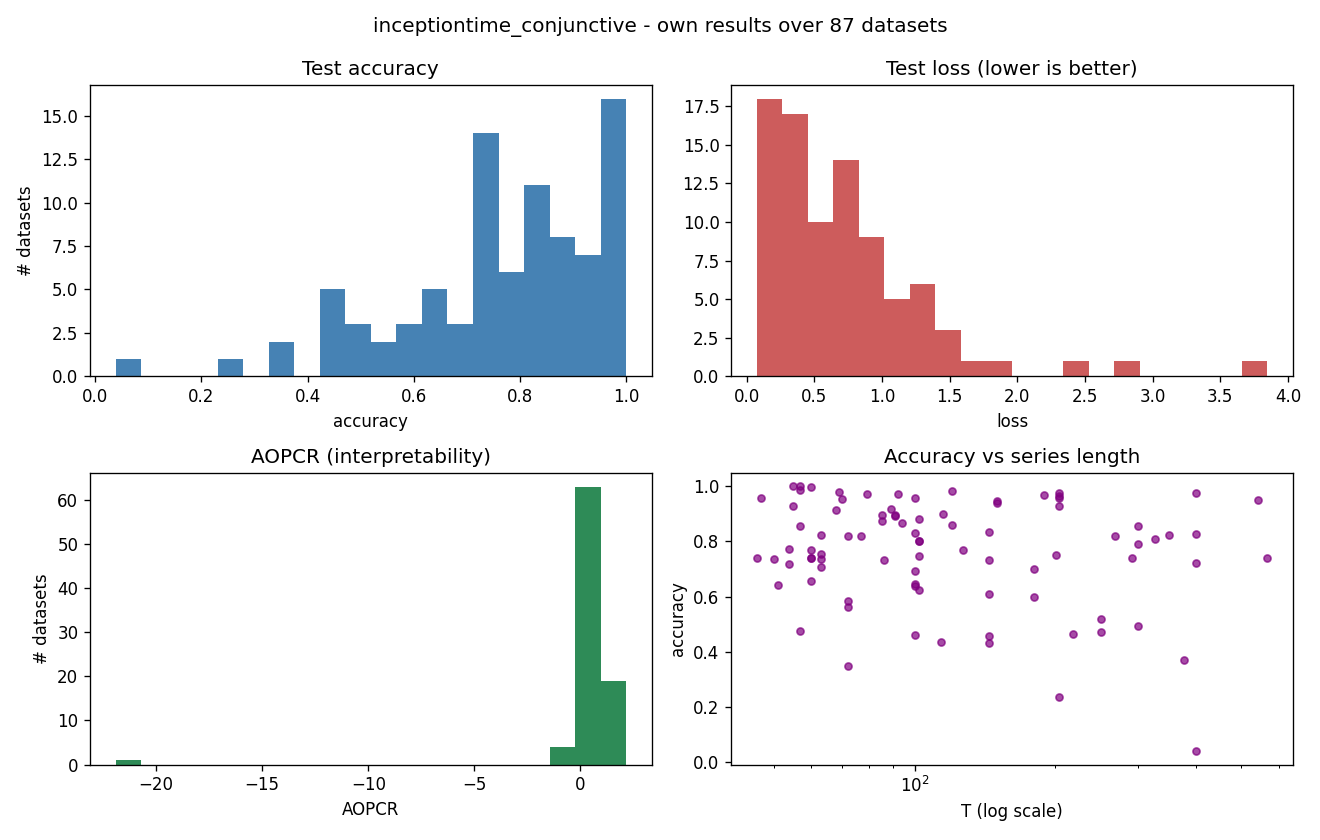

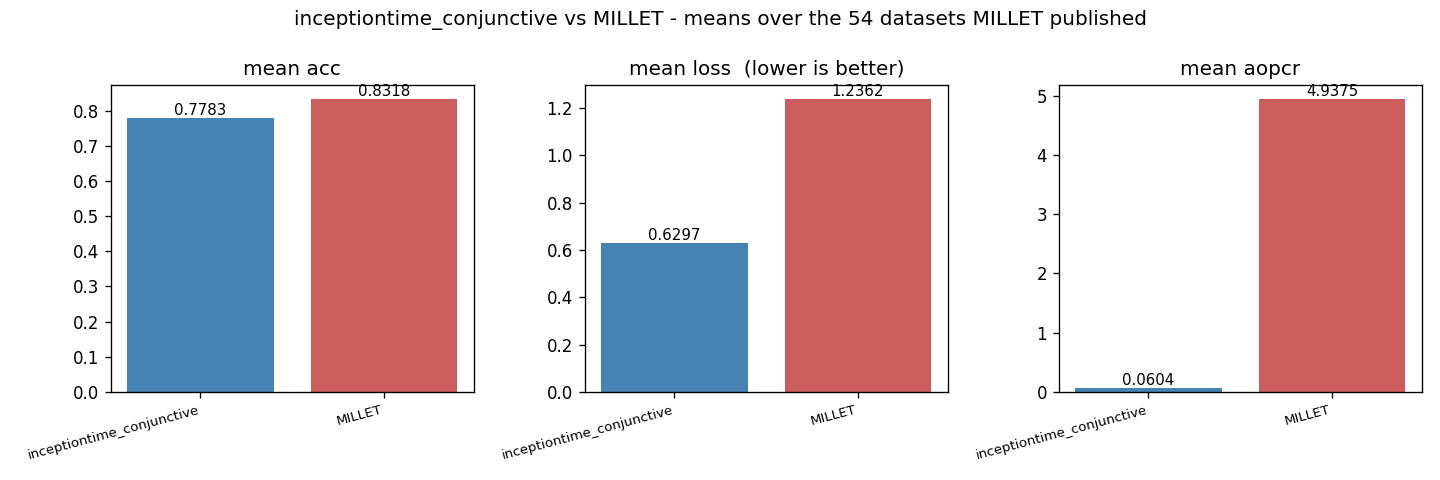

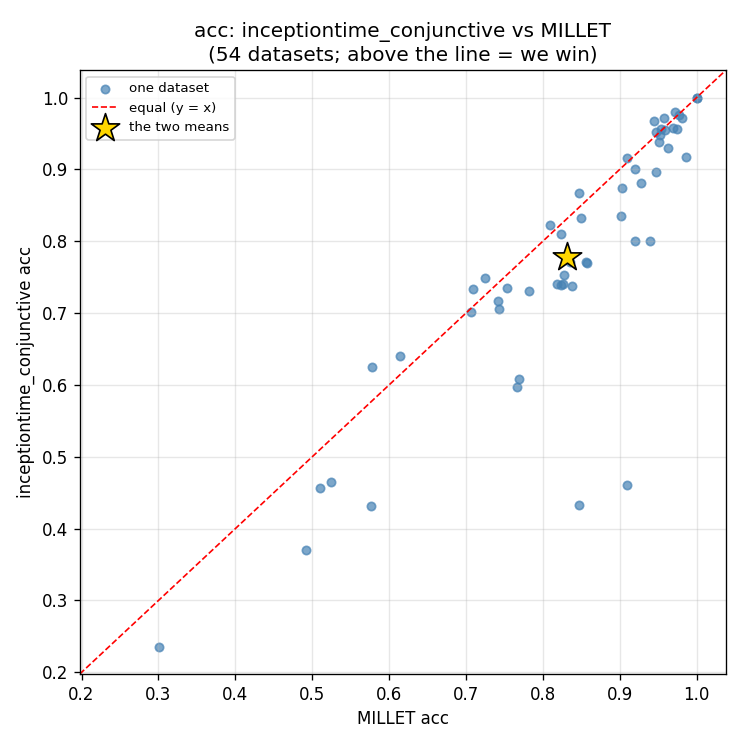

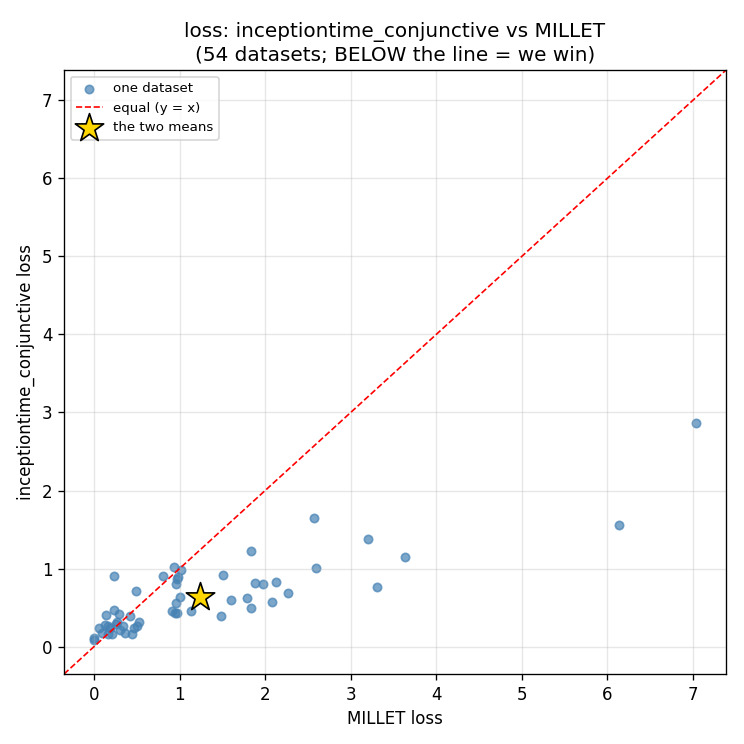

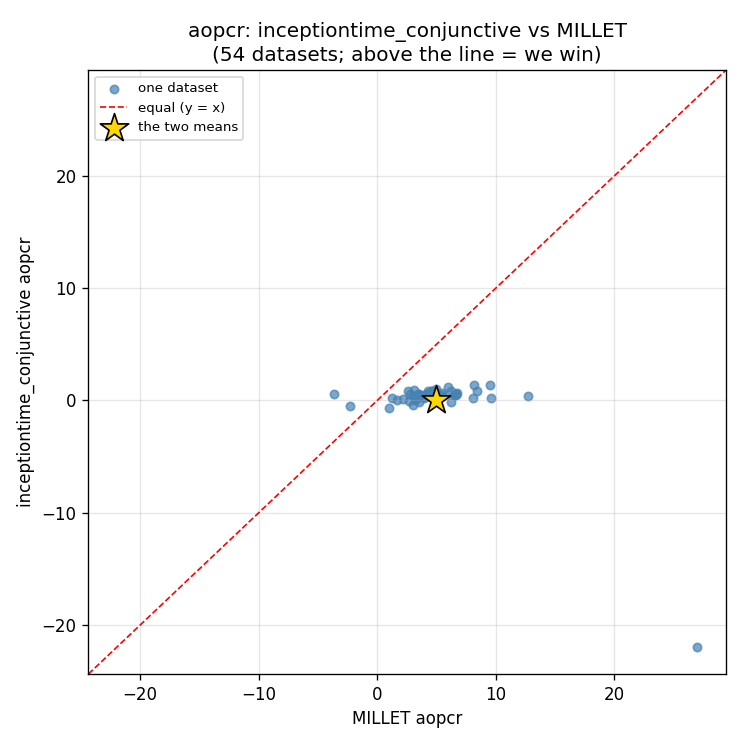

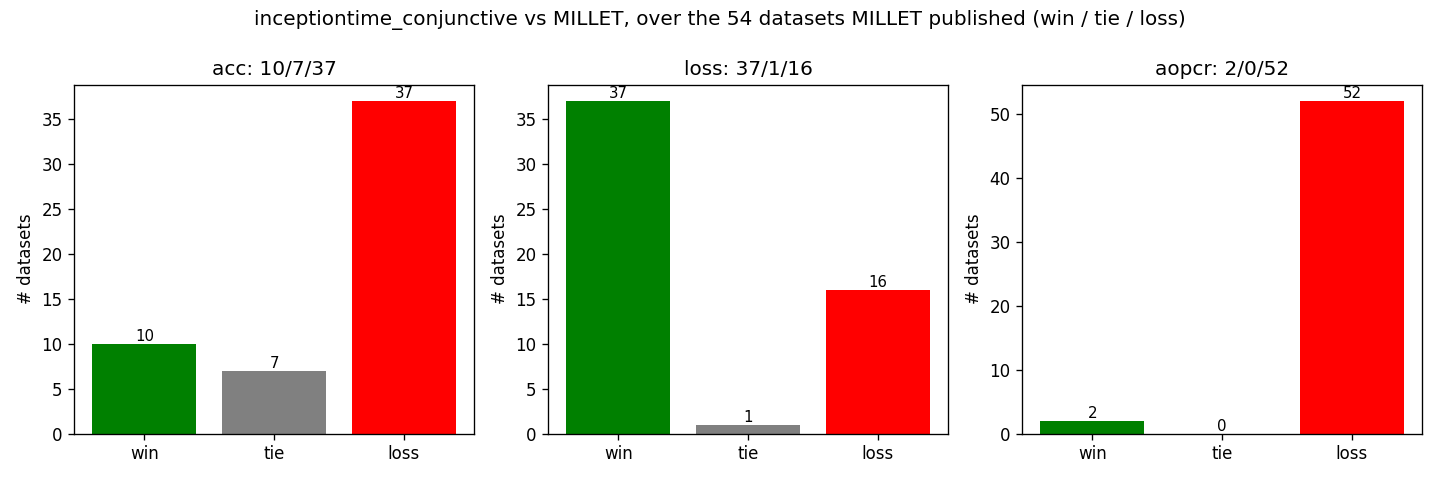

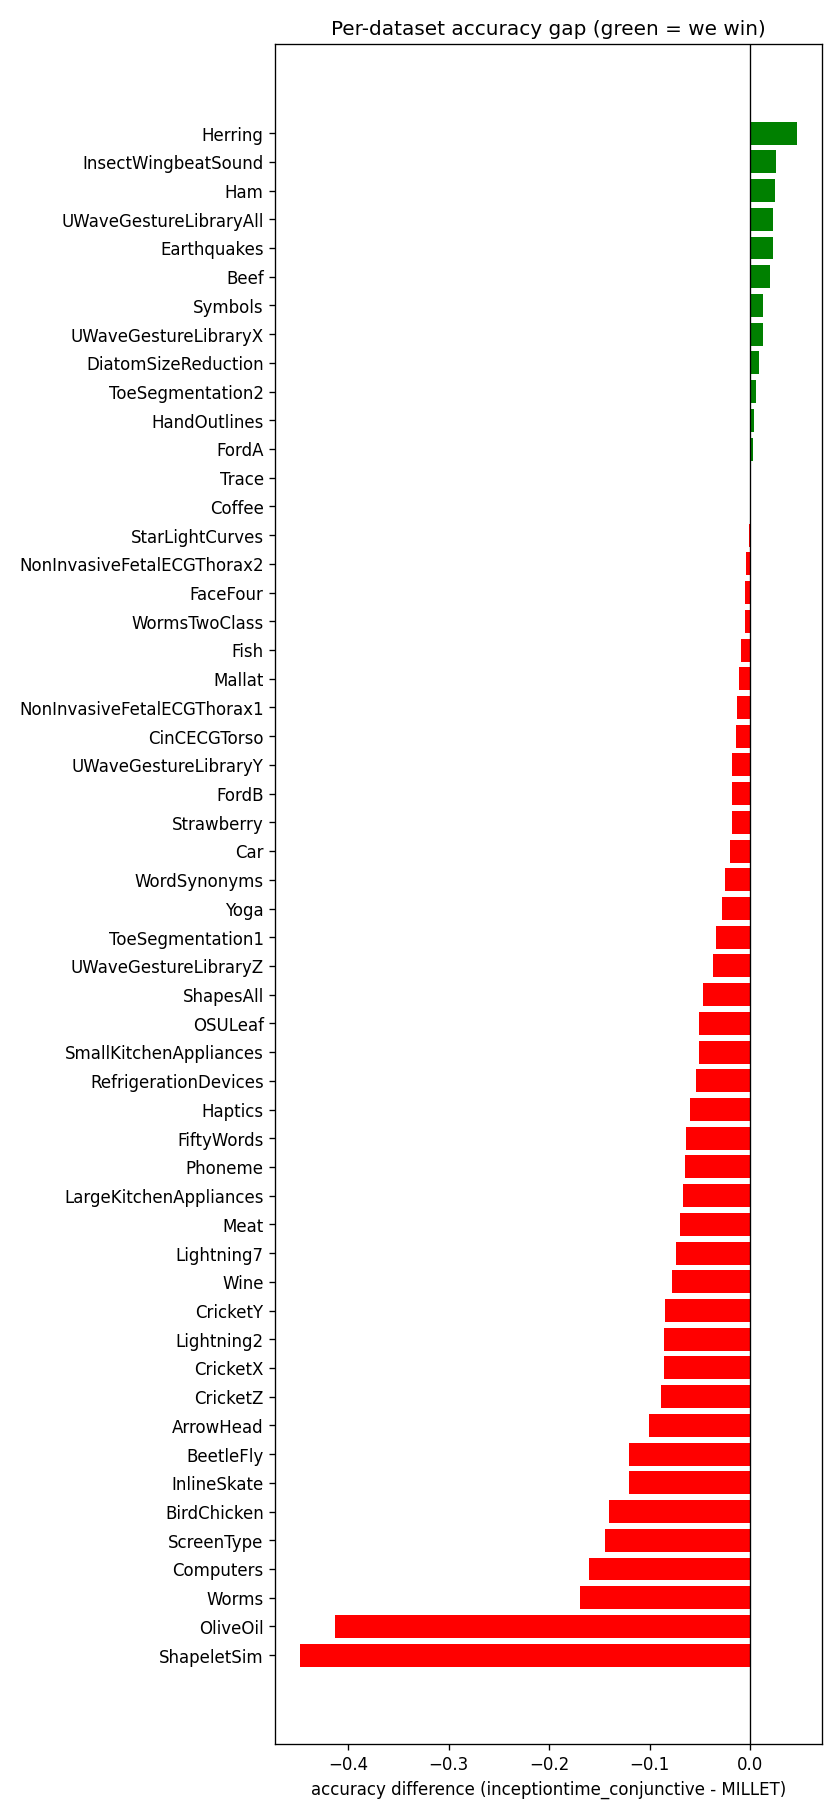

mstcn_sep_adaptive_classwise


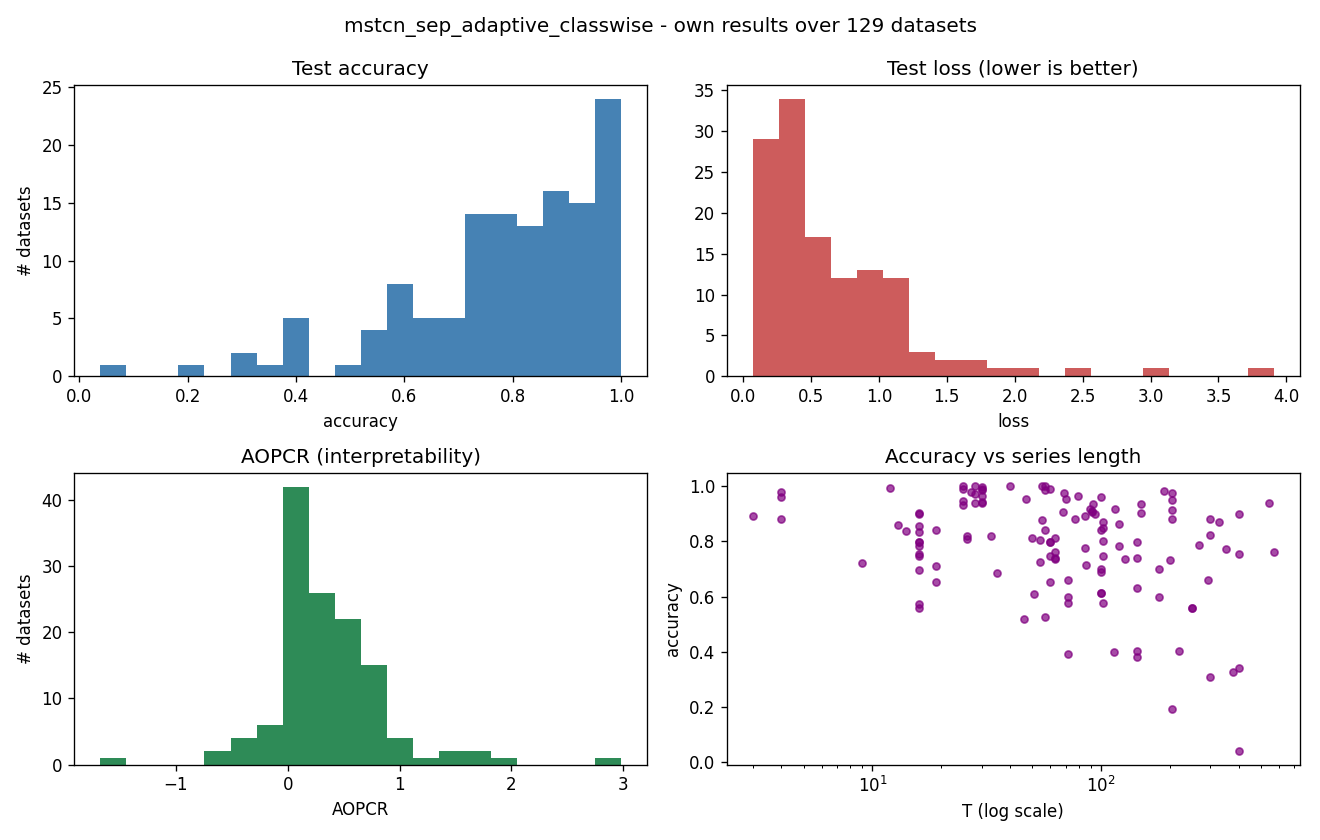

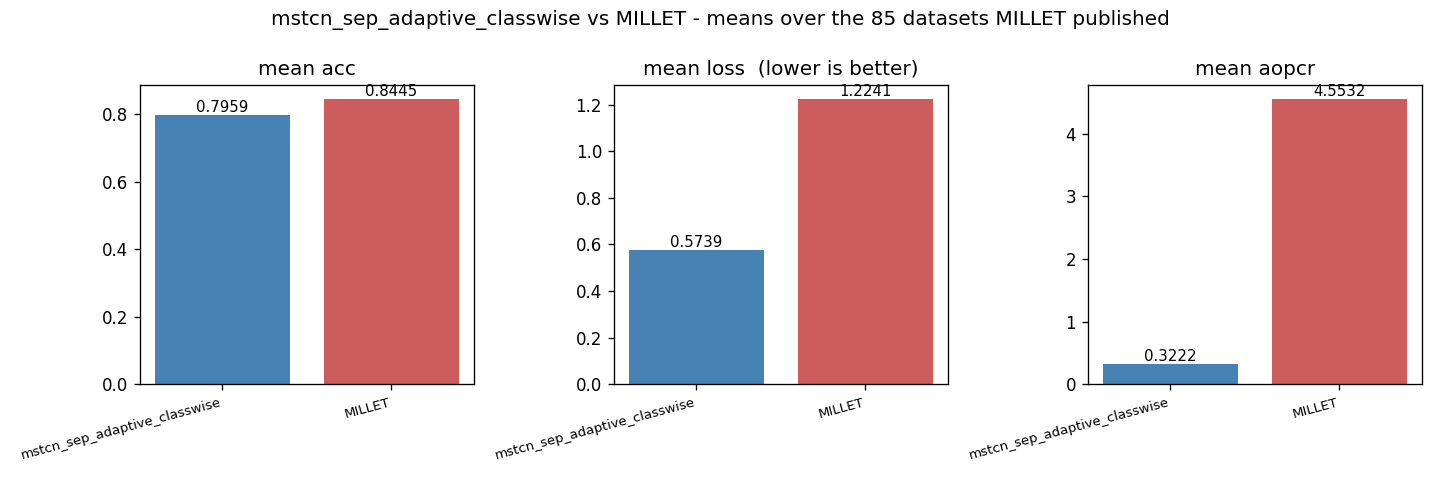

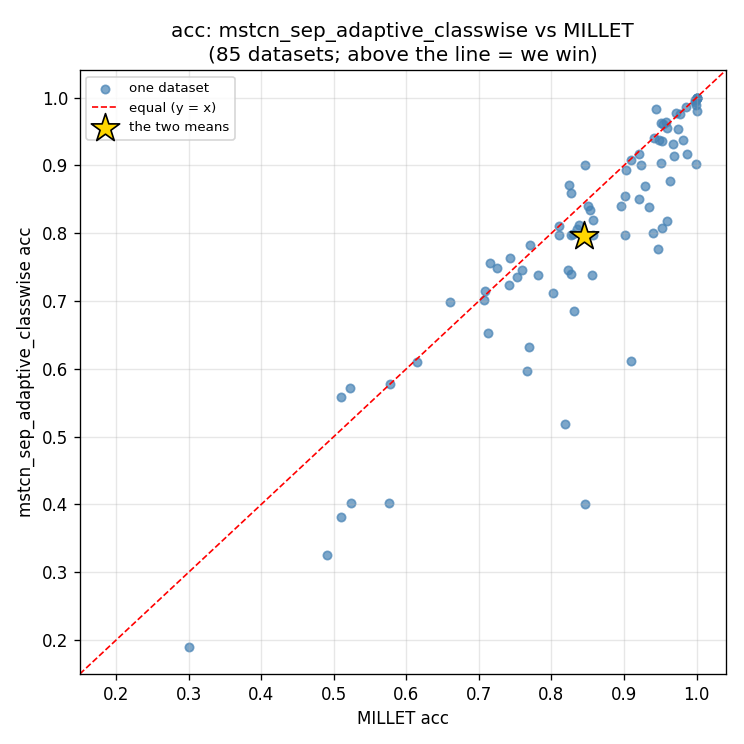

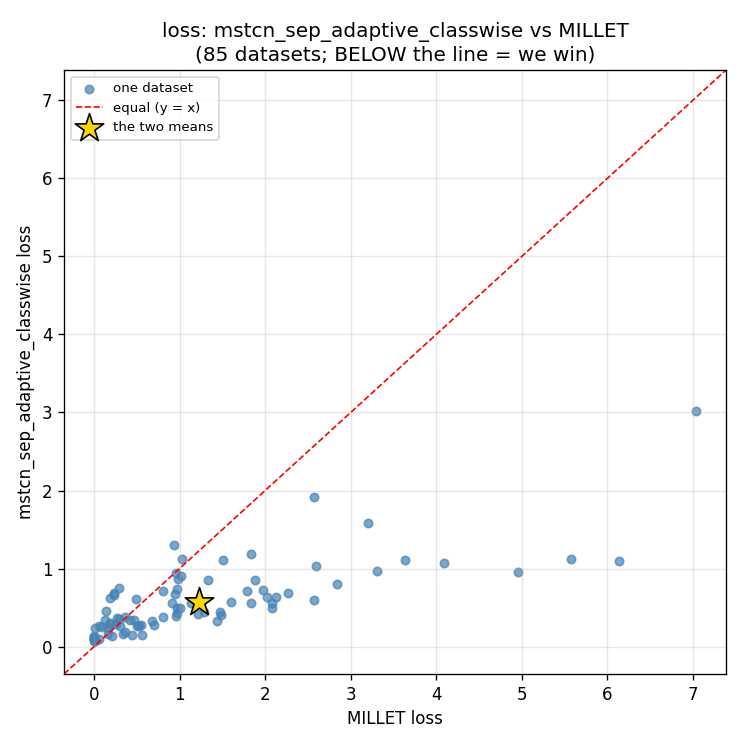

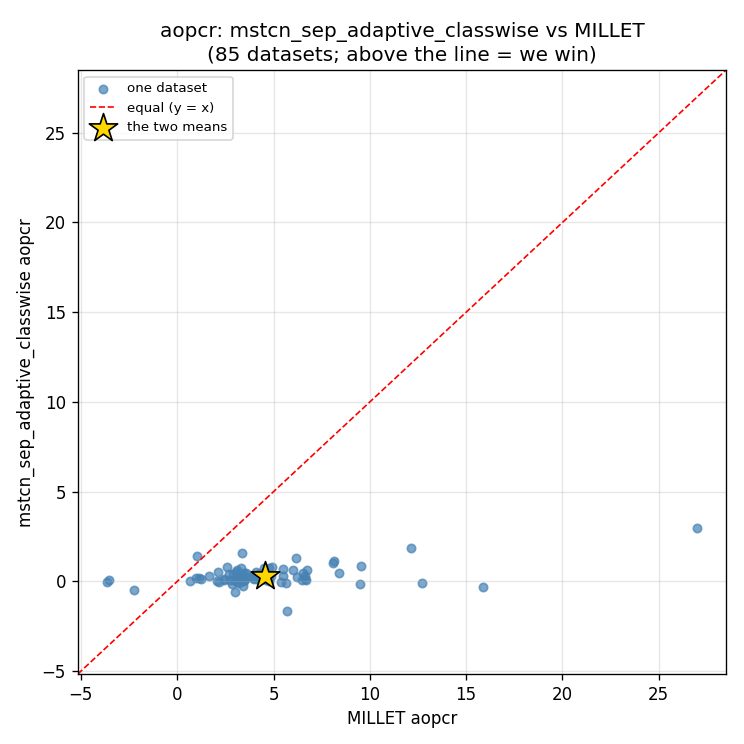

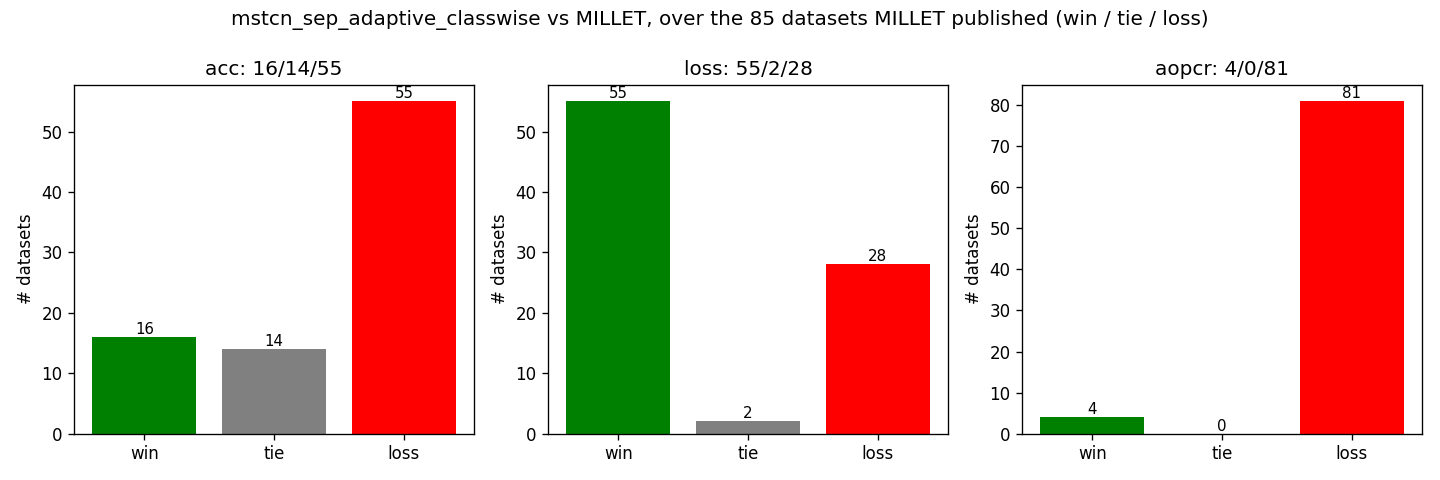

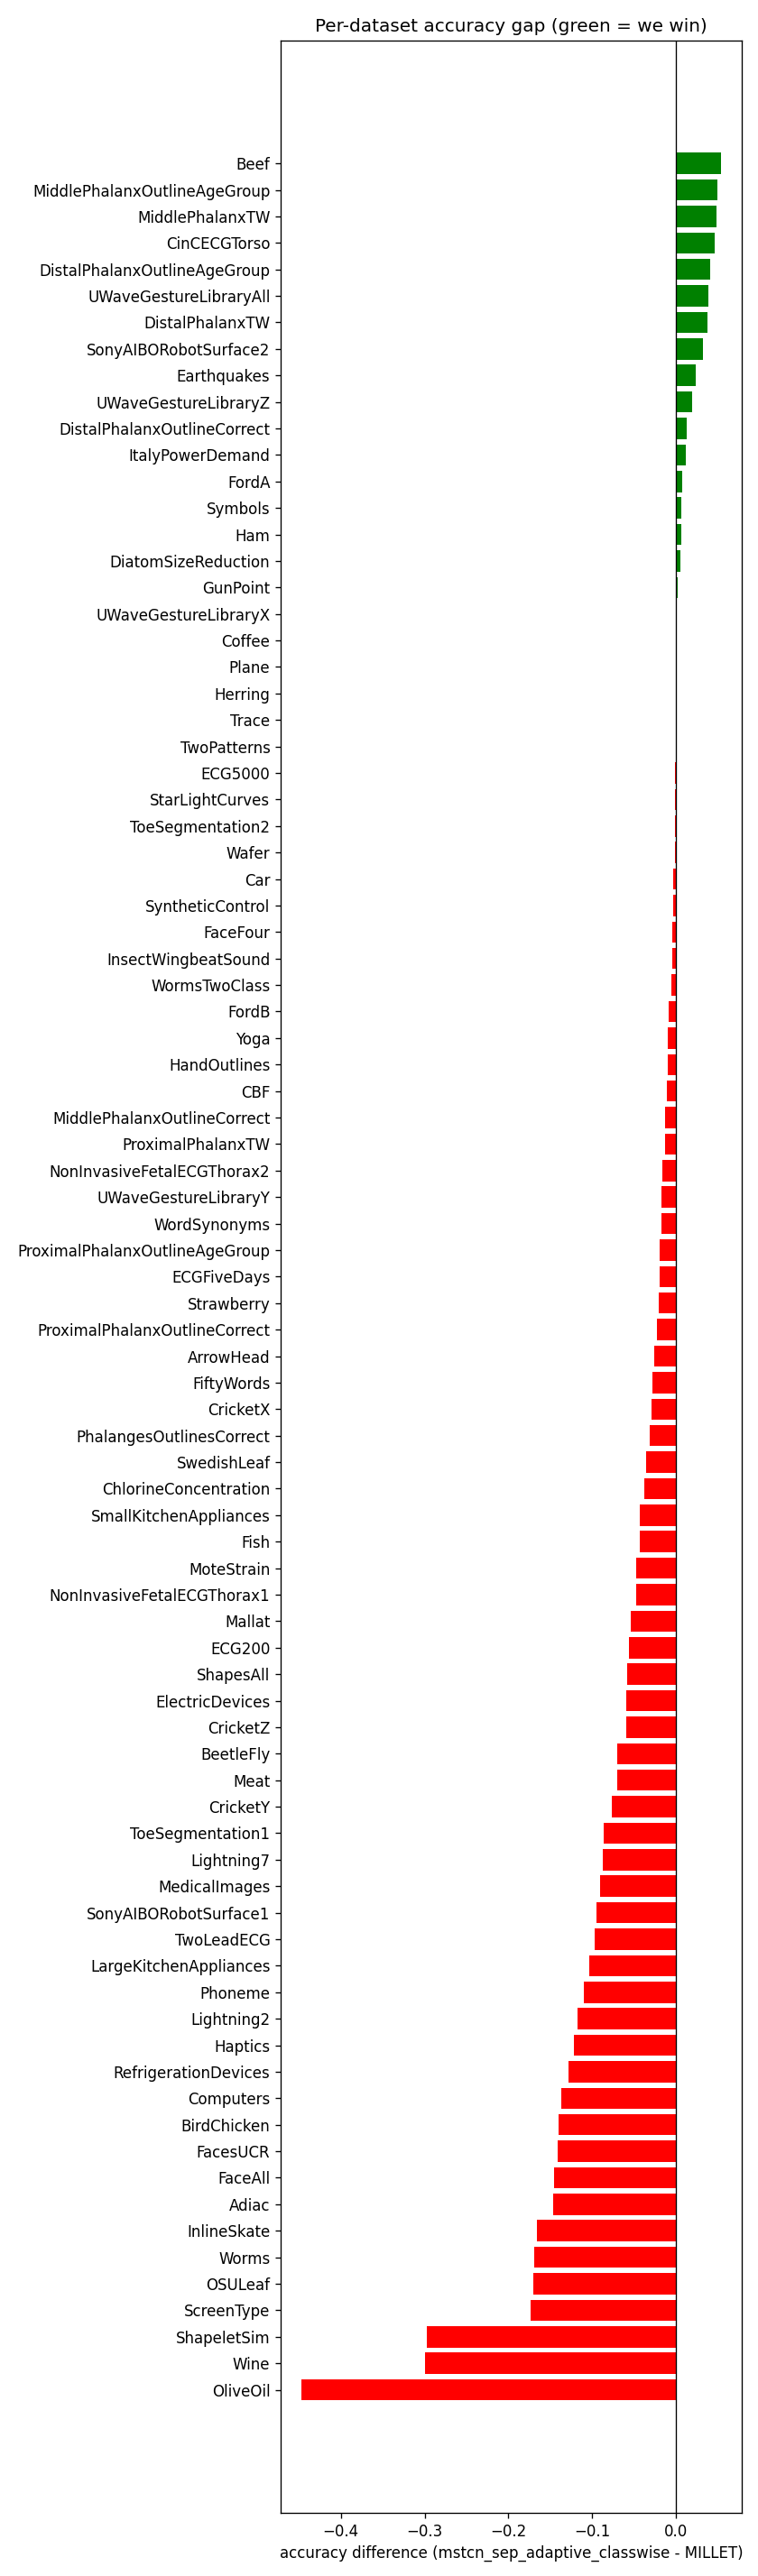

mstcn_sep_additive


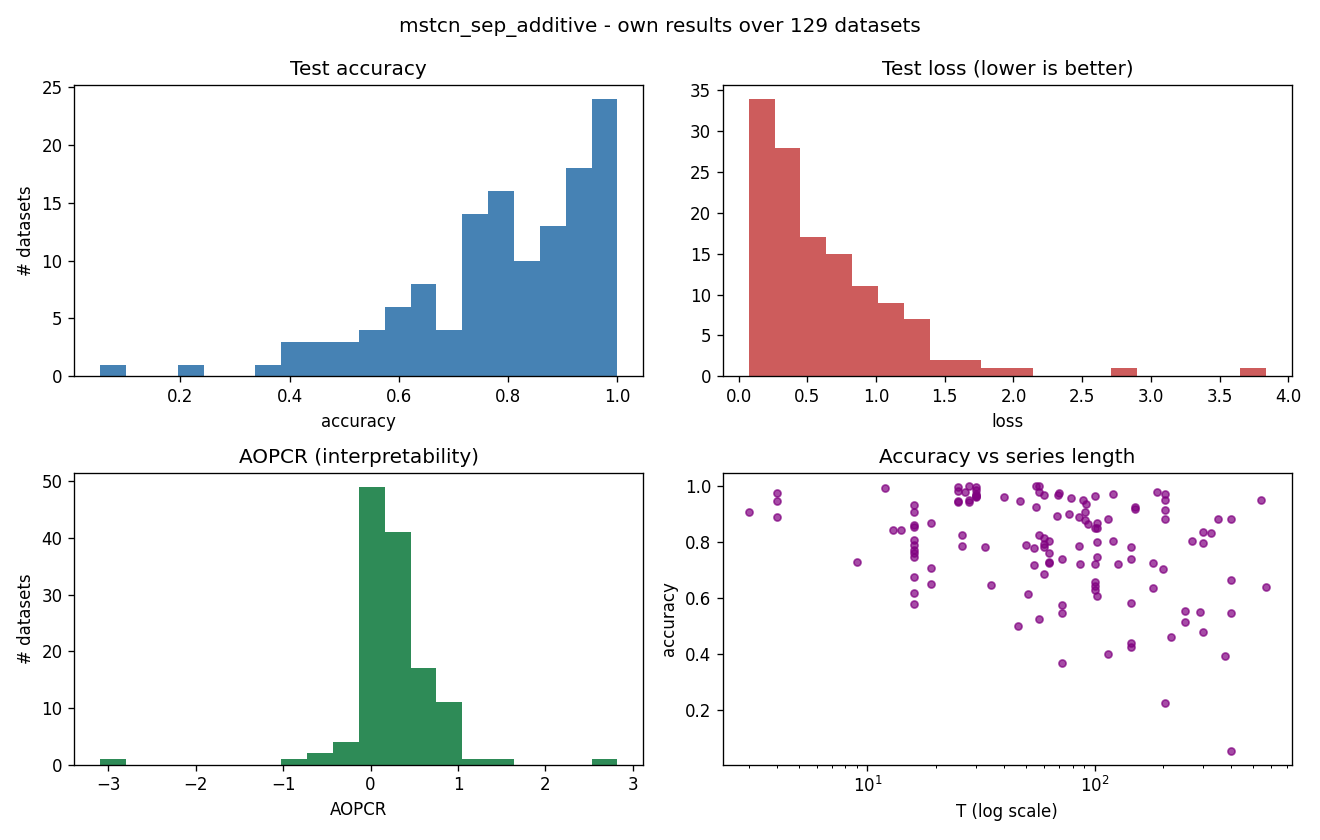

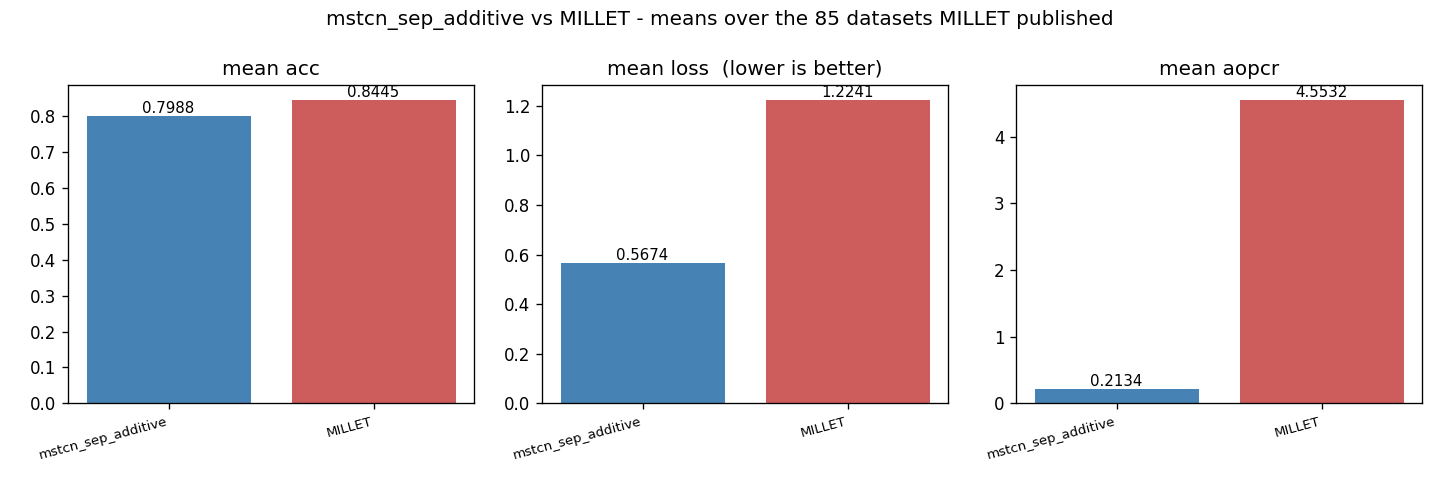

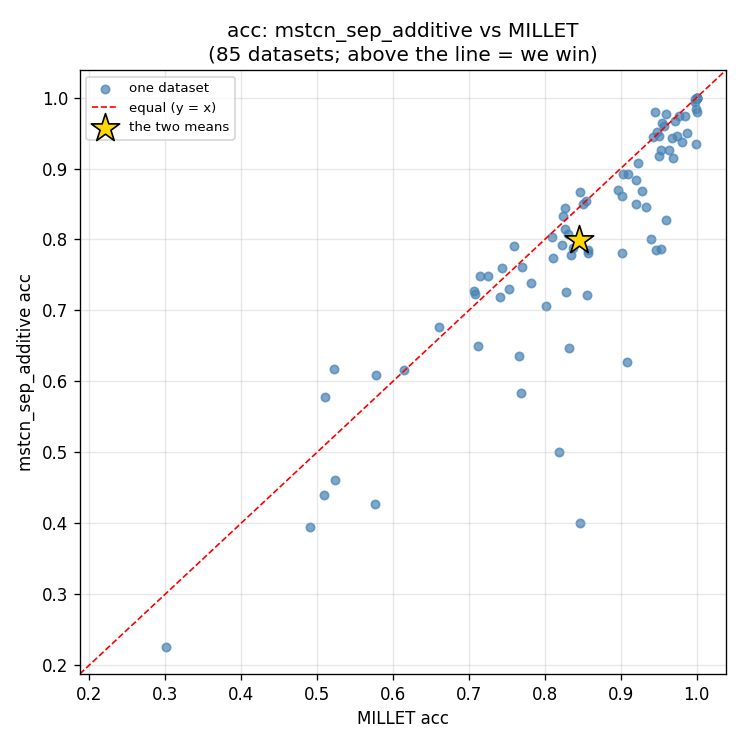

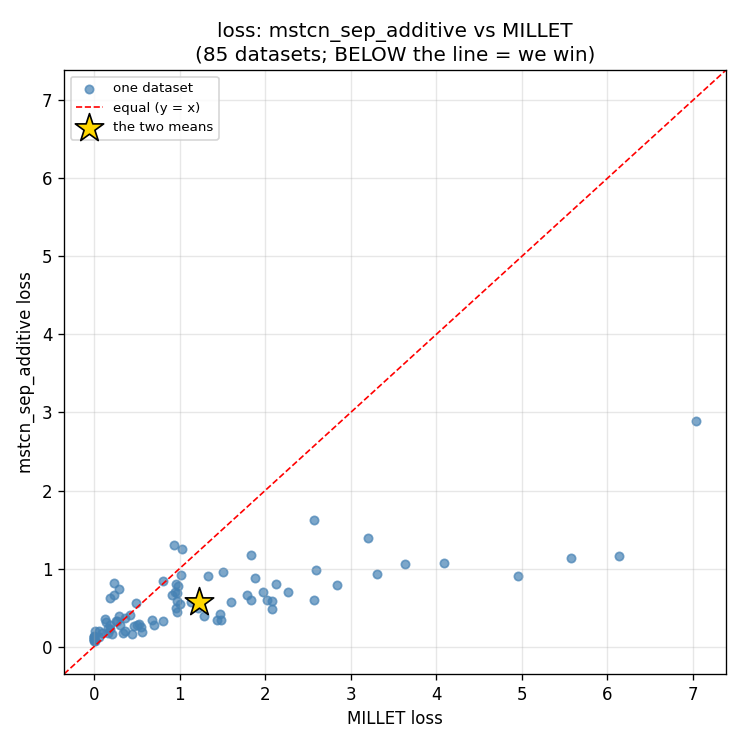

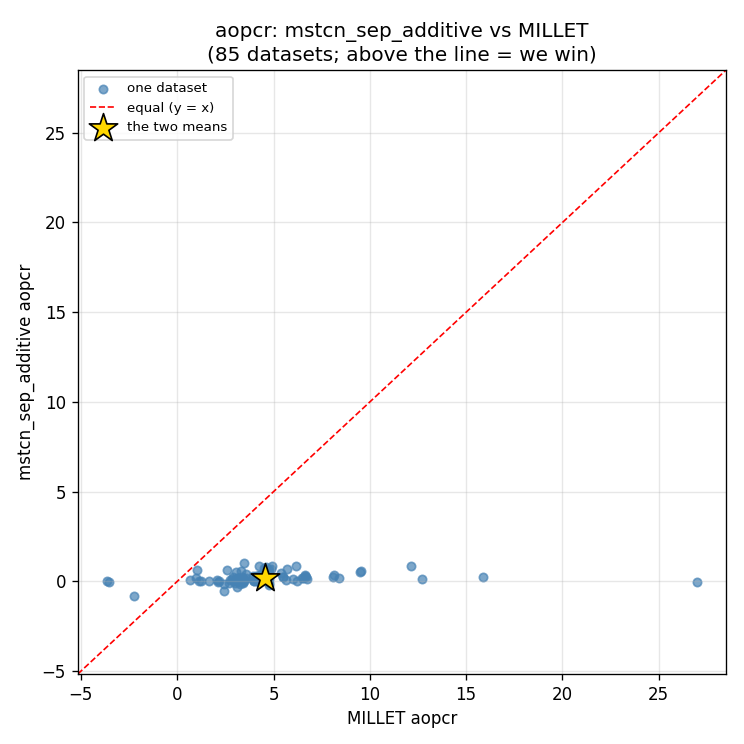

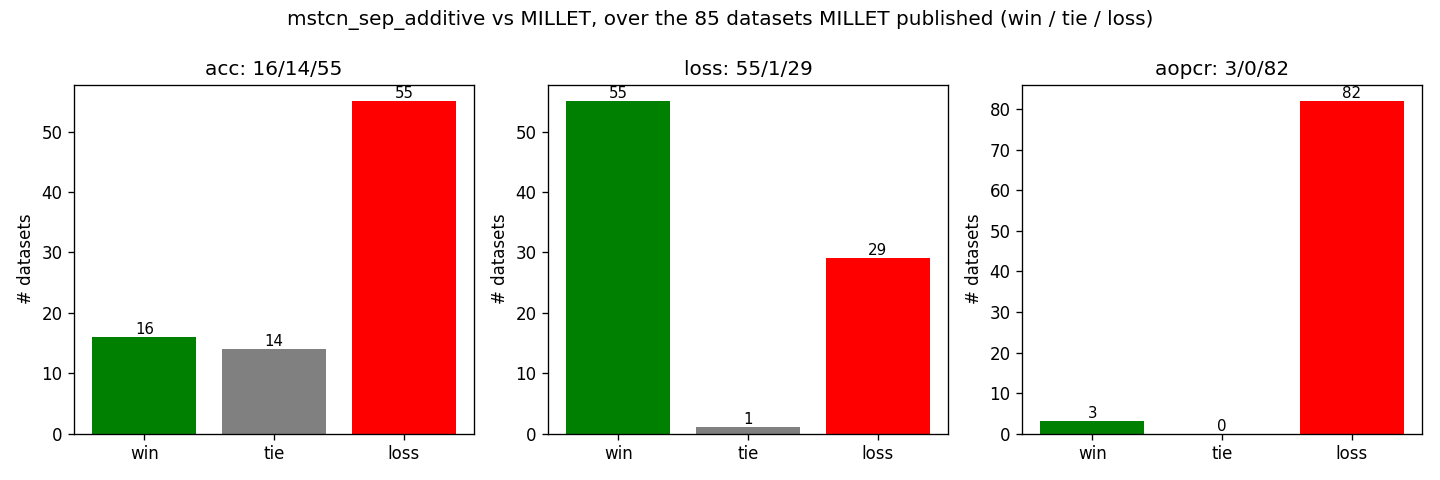

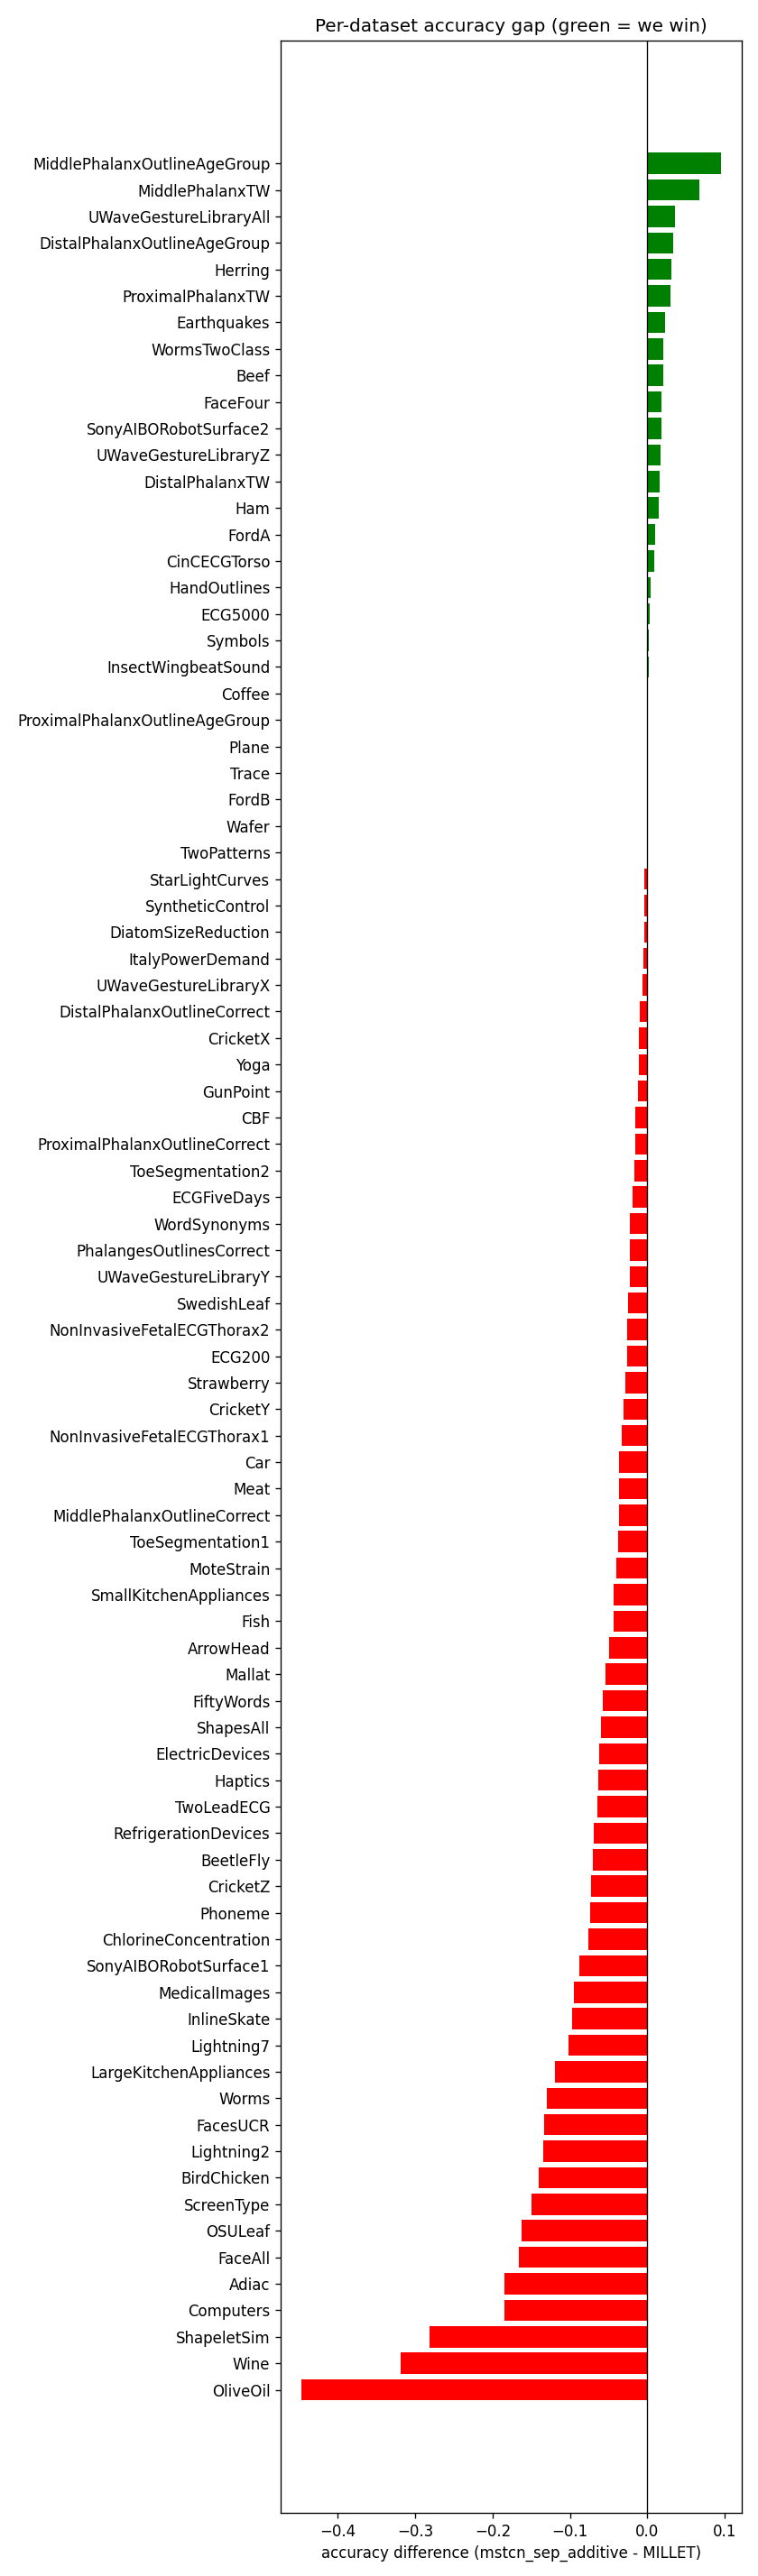

mstcn_sep_classwise_conjunctive


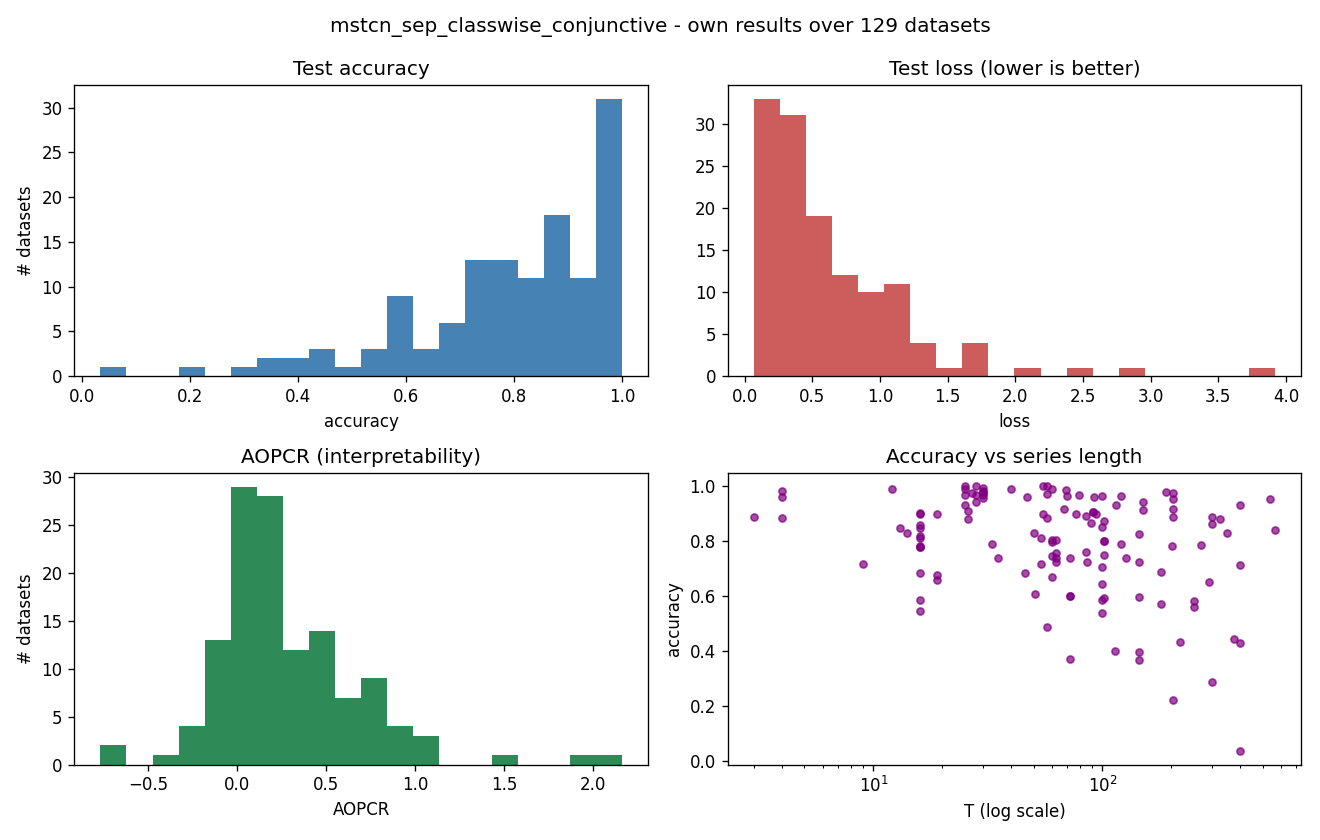

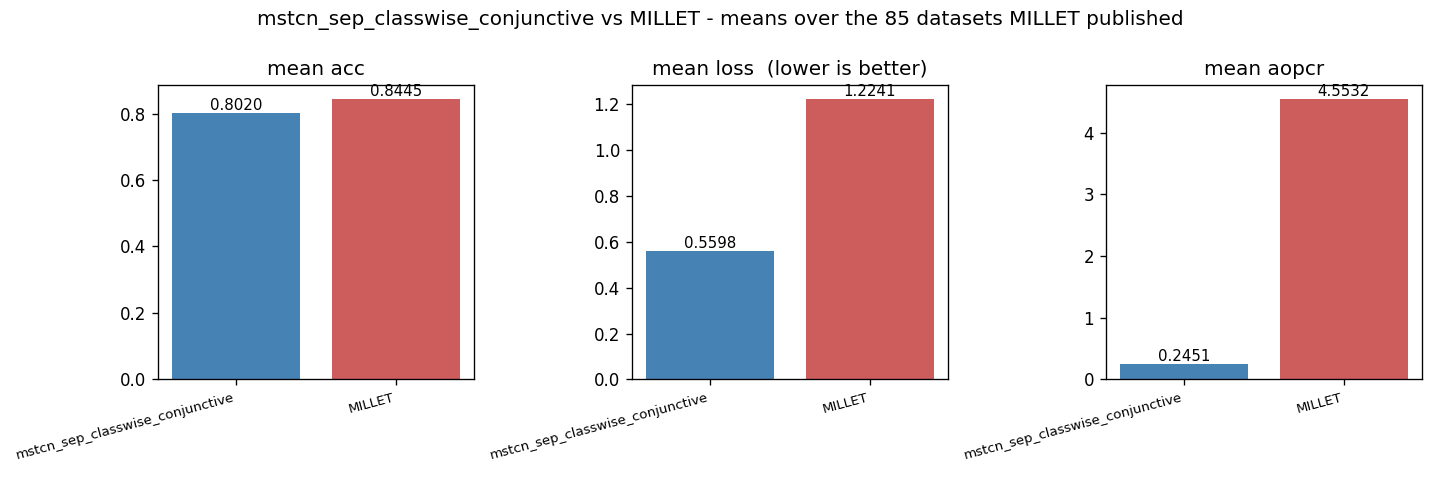

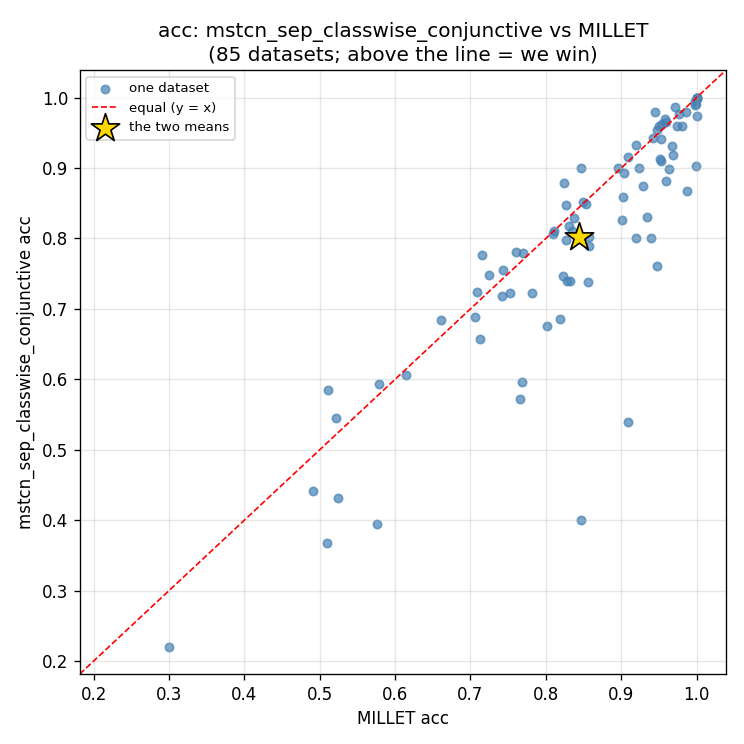

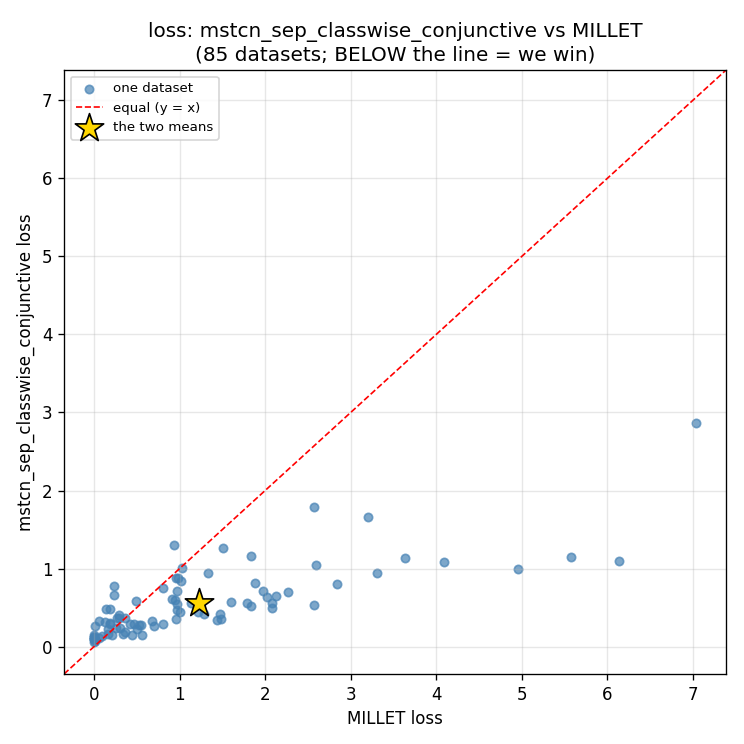

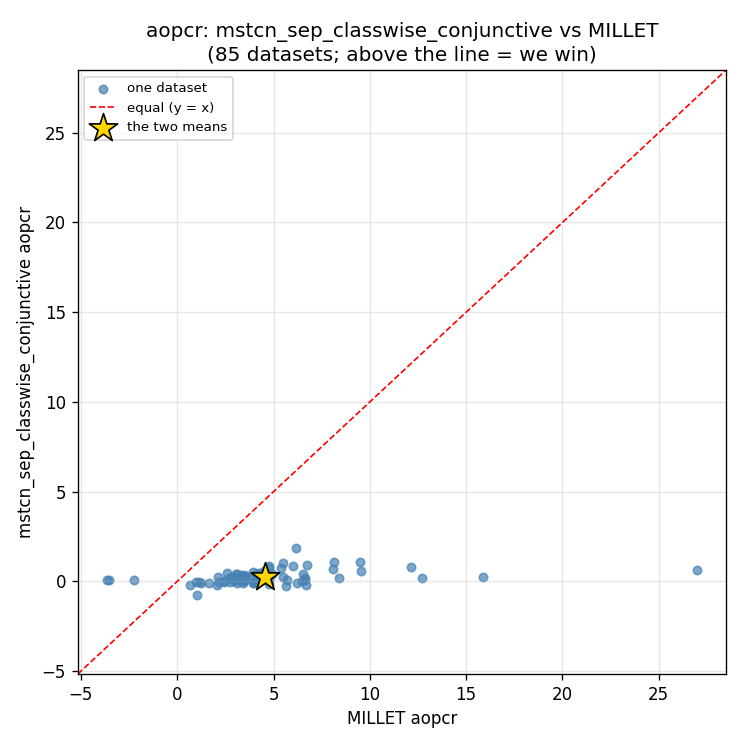

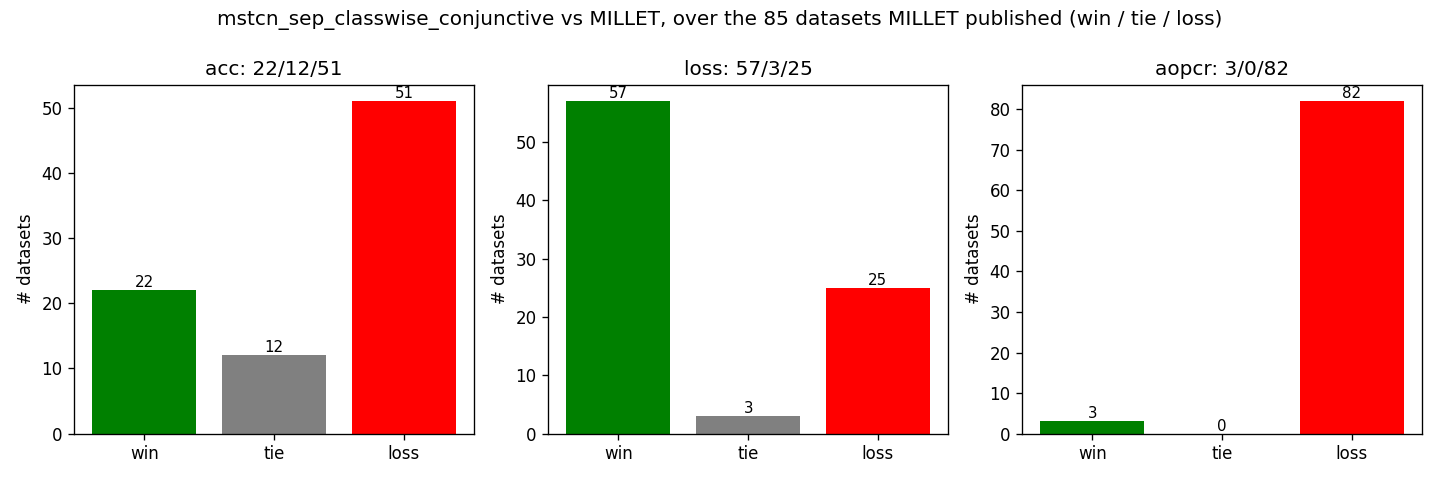

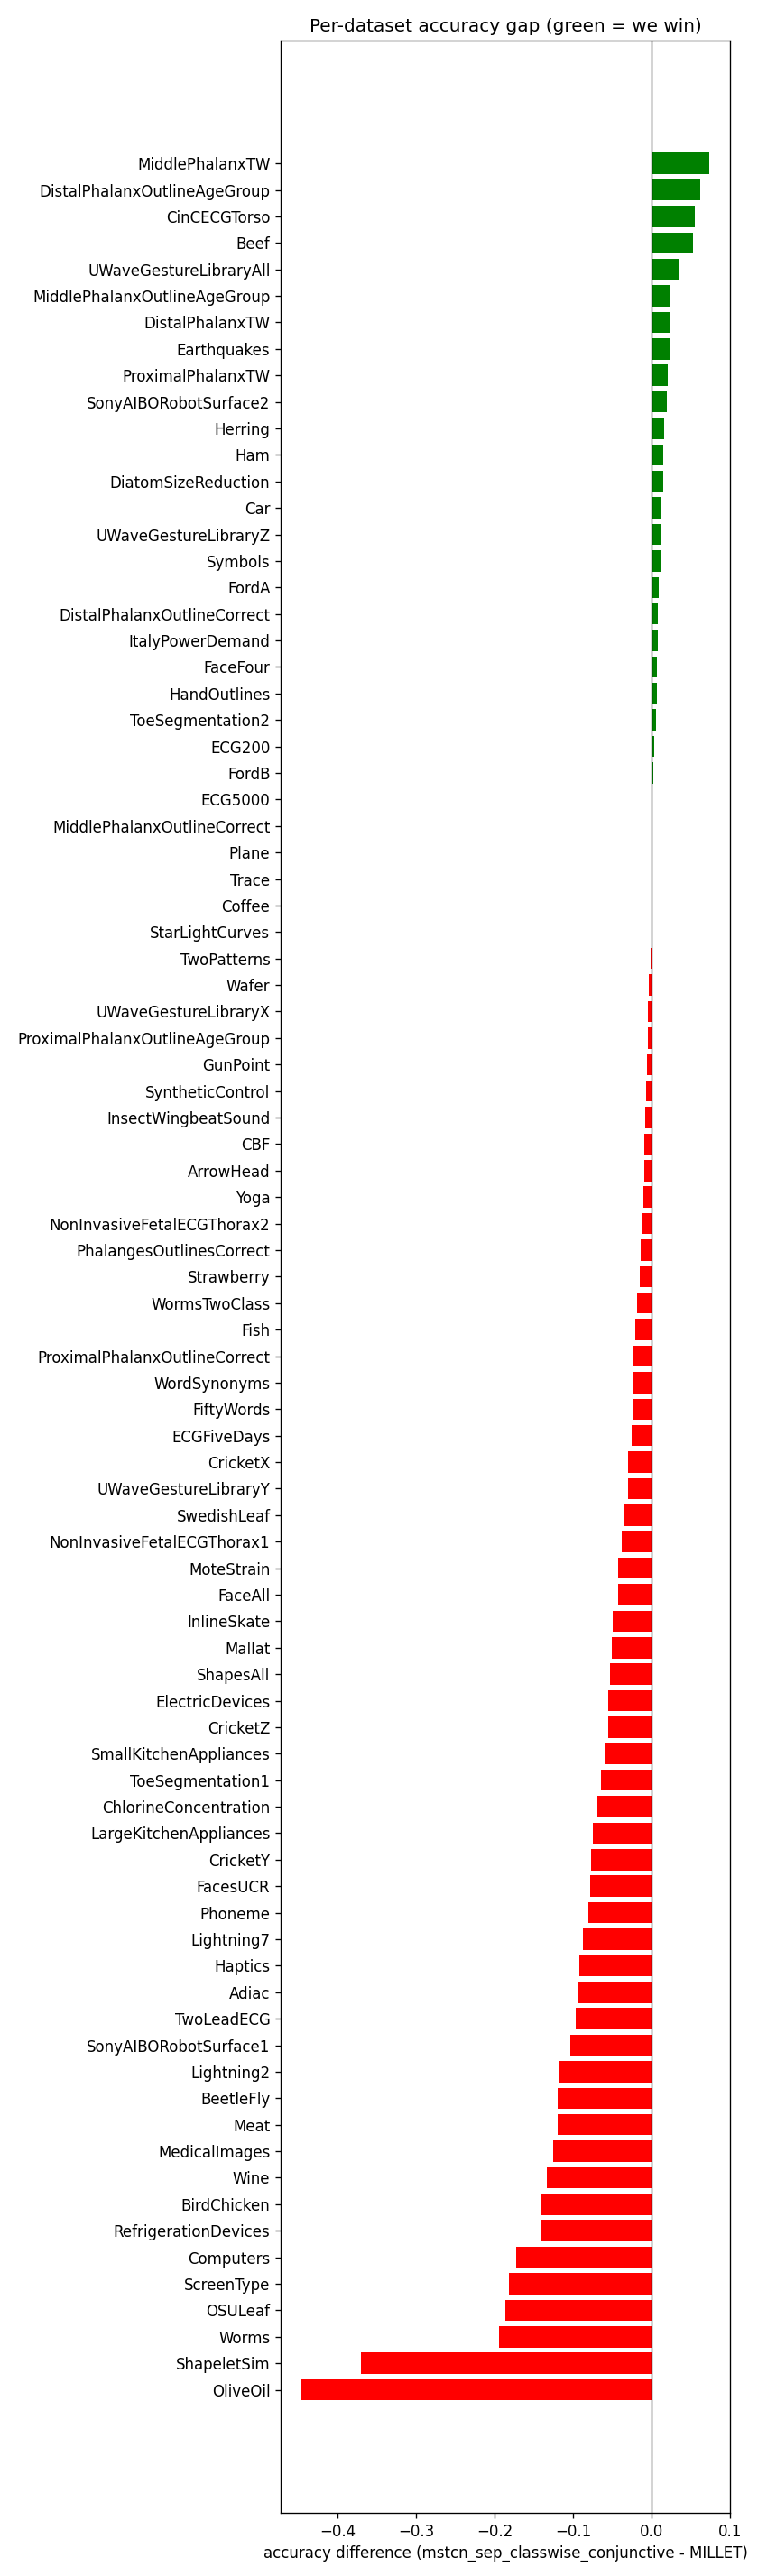

mstcn_sep_conjunctive


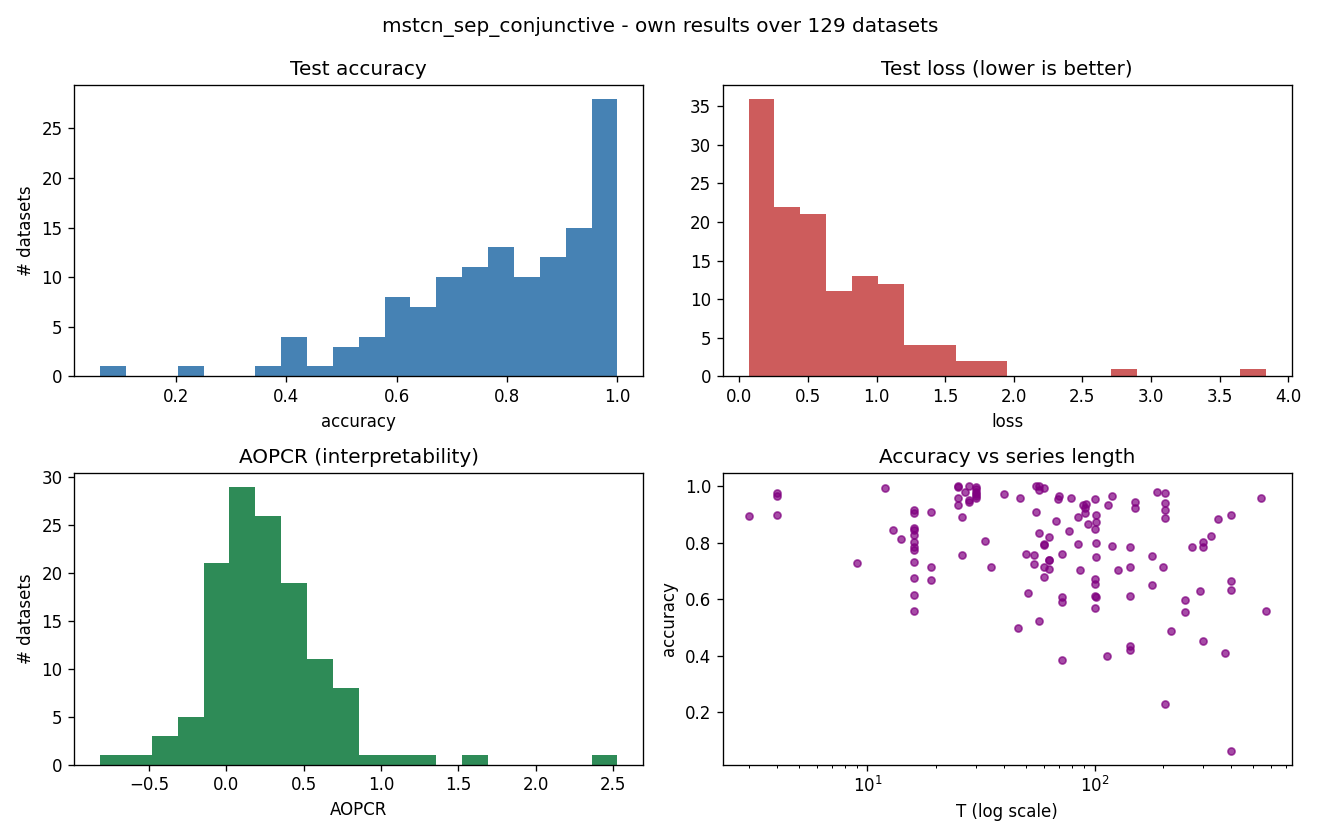

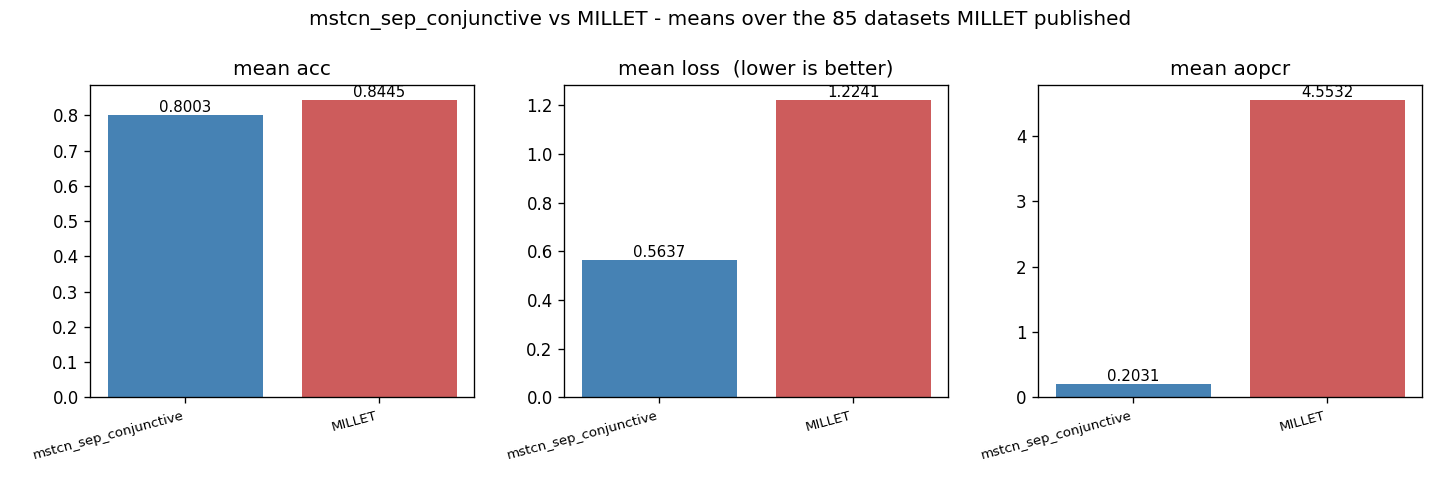

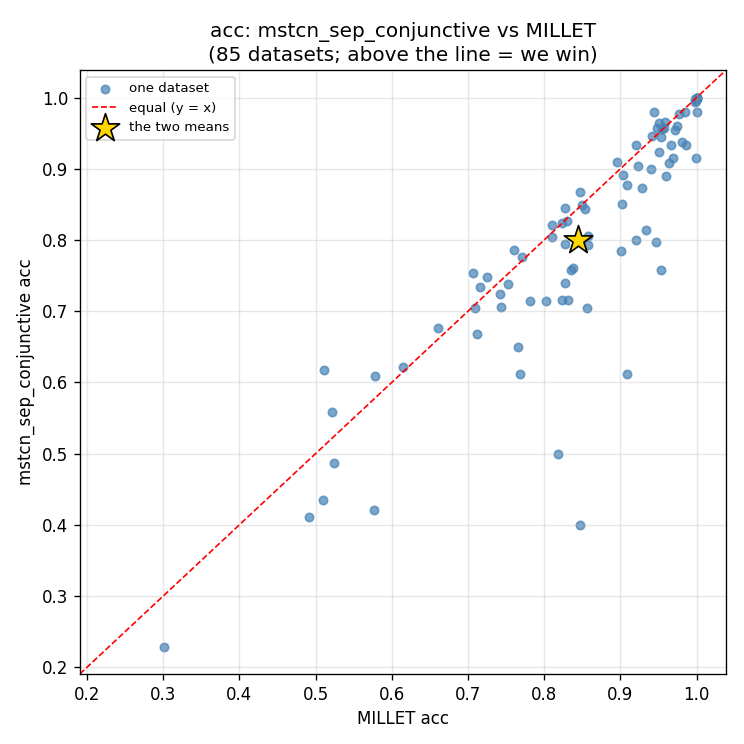

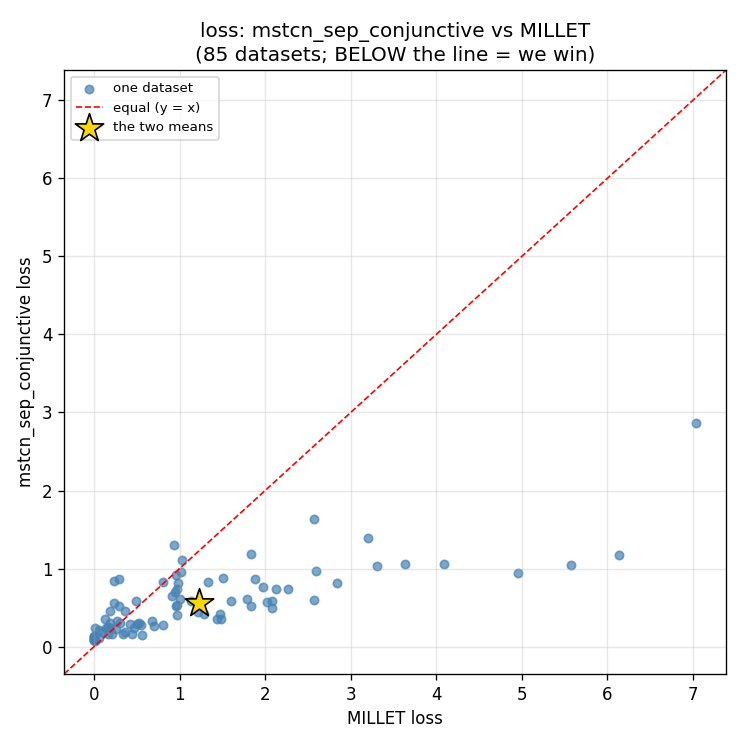

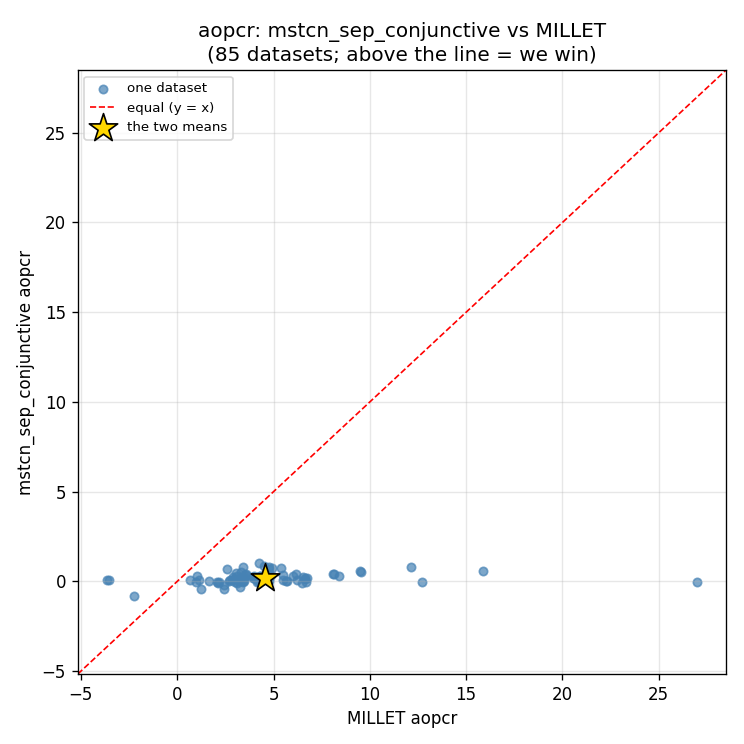

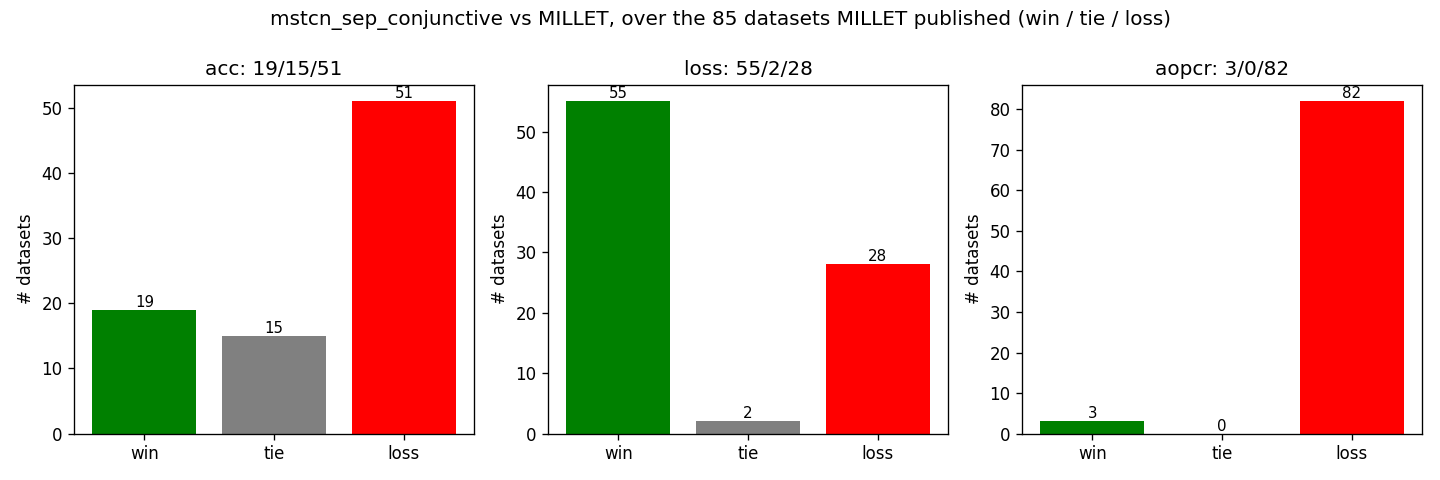

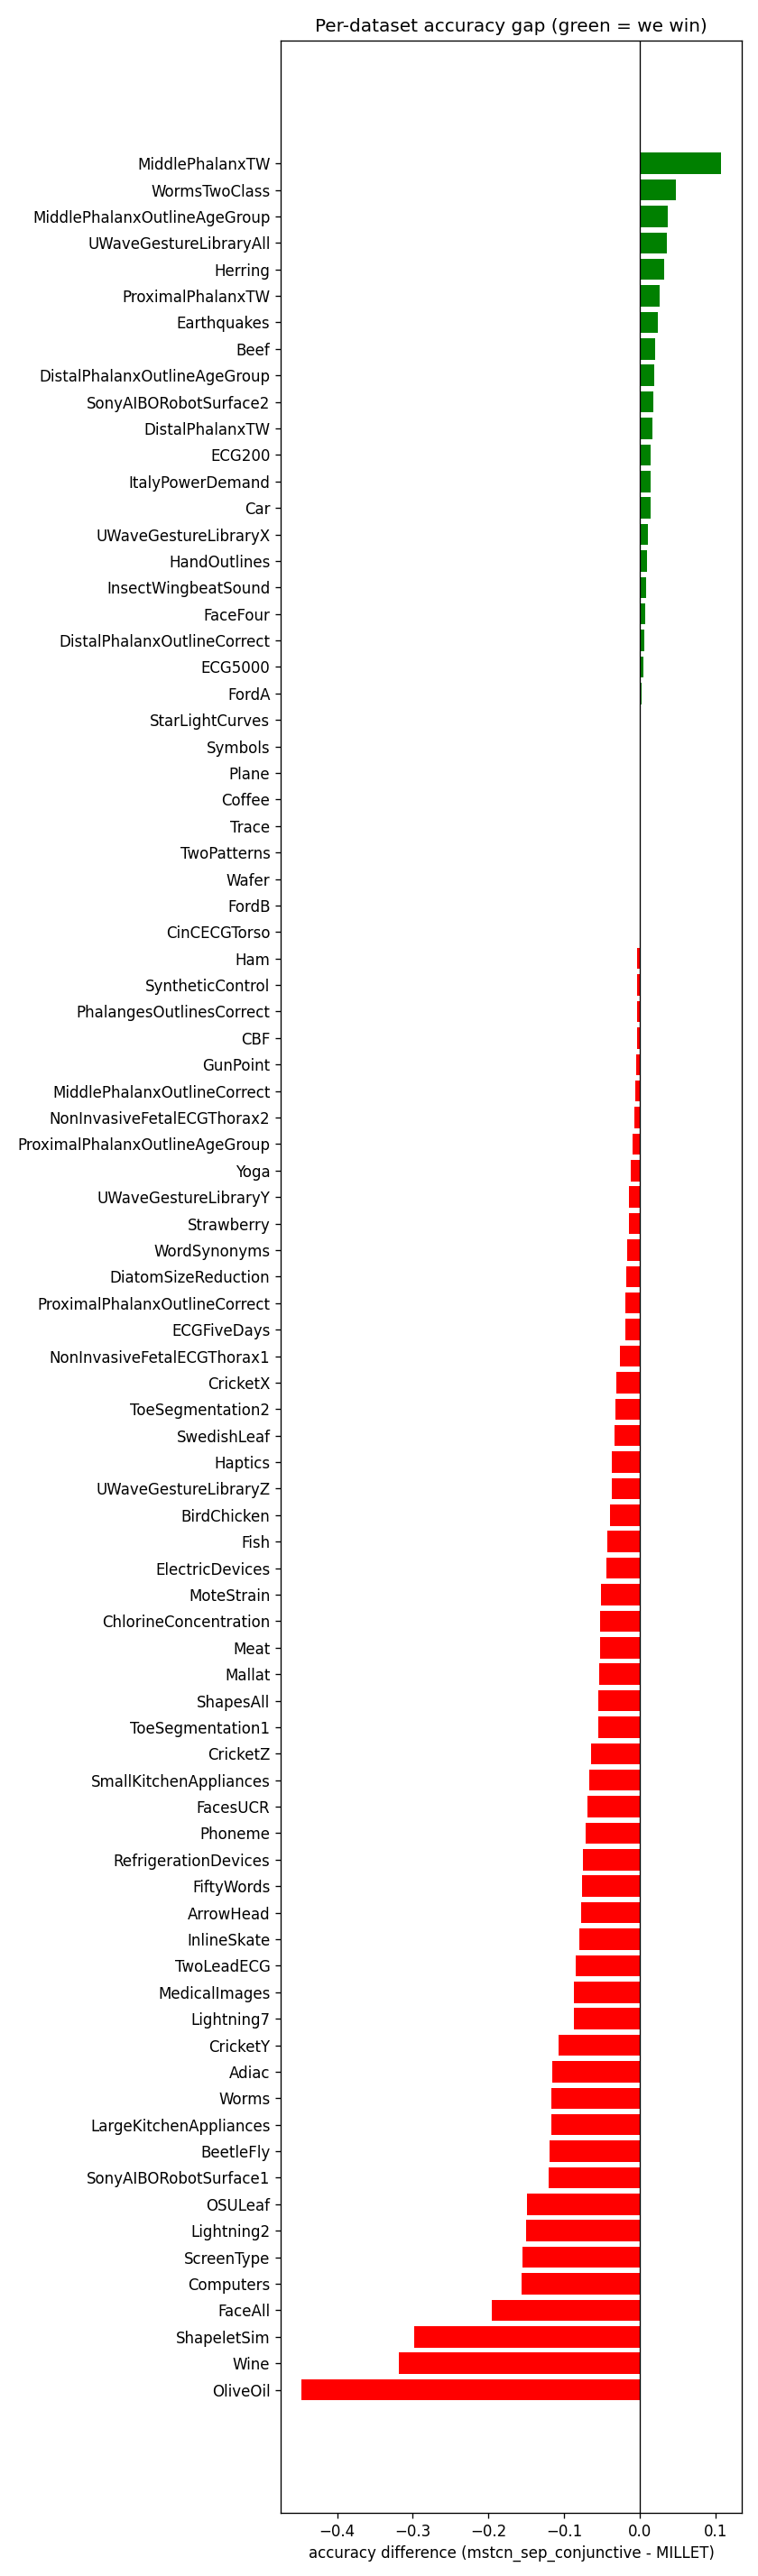

mstcn_sep_softmax_conjunctive


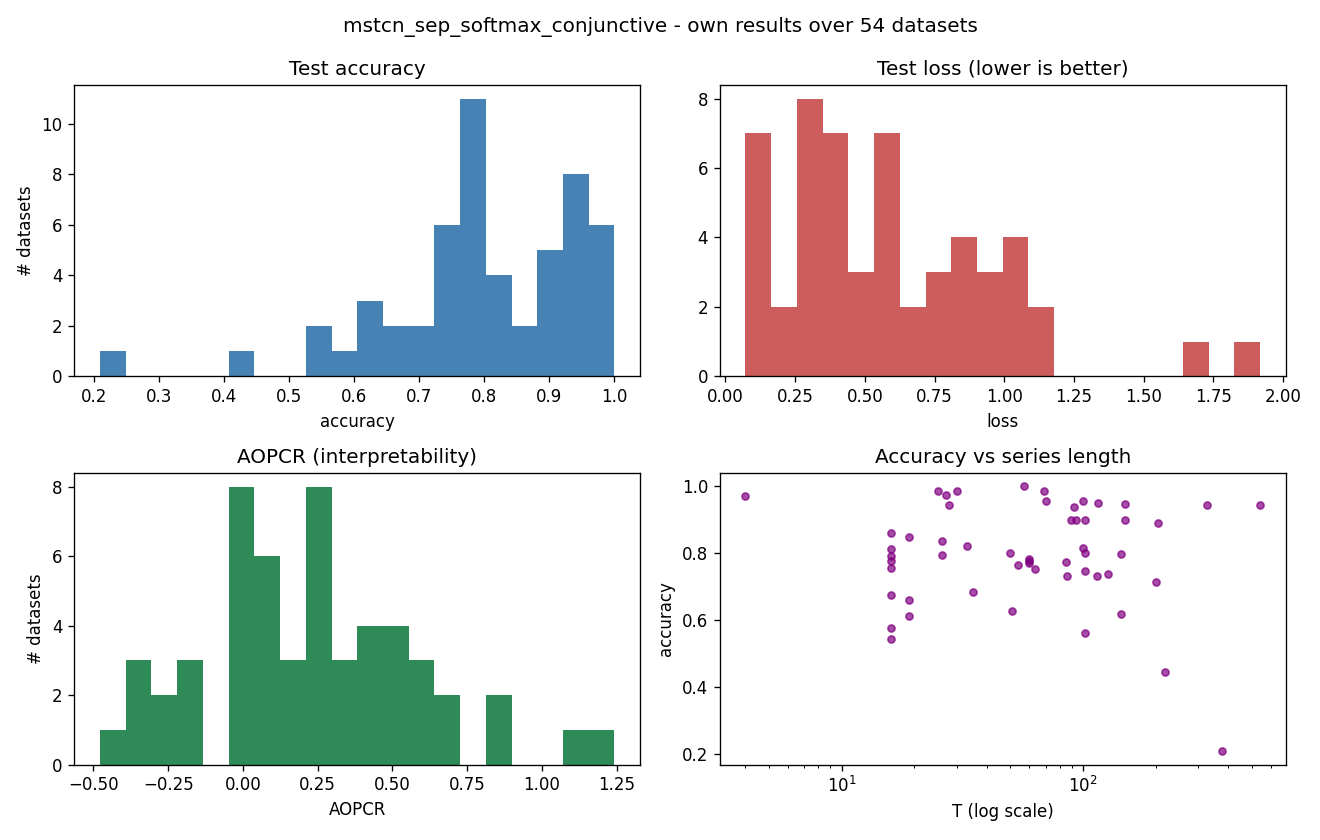

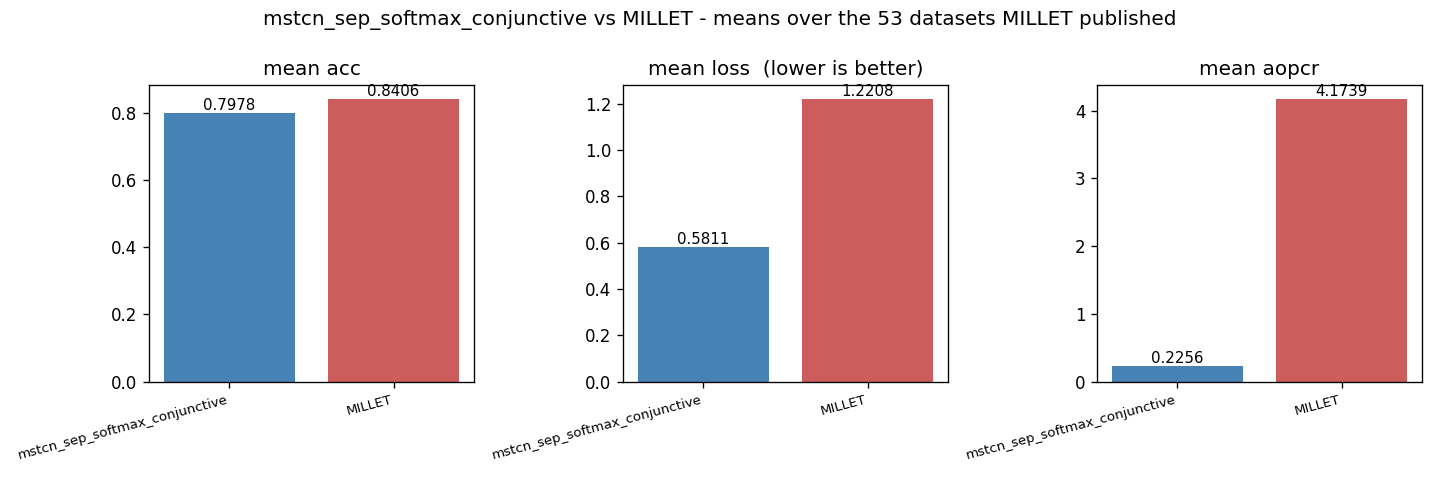

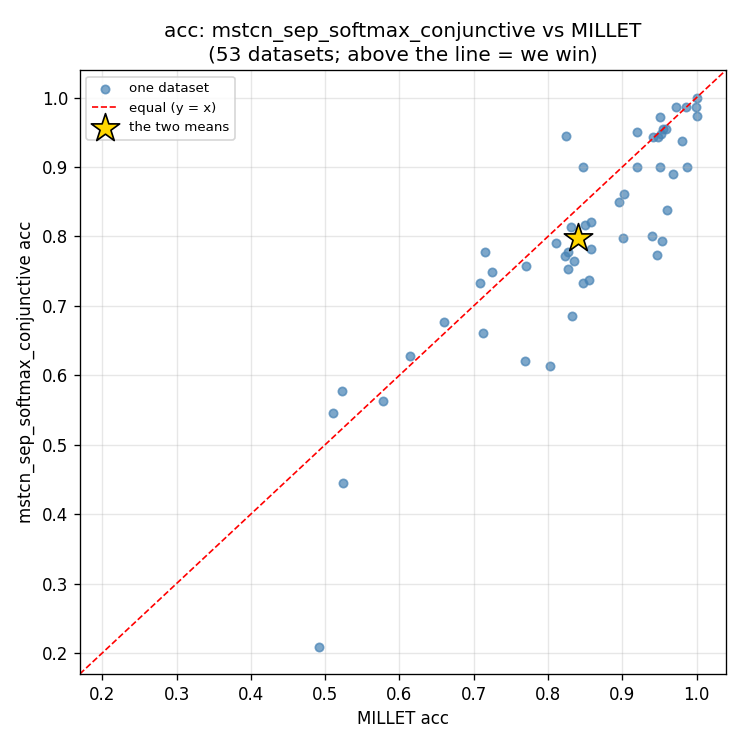

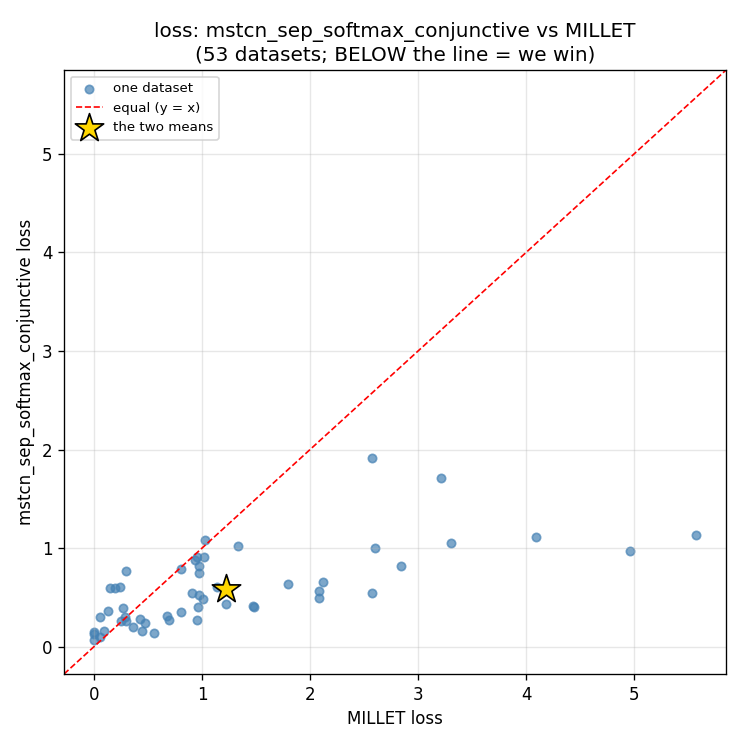

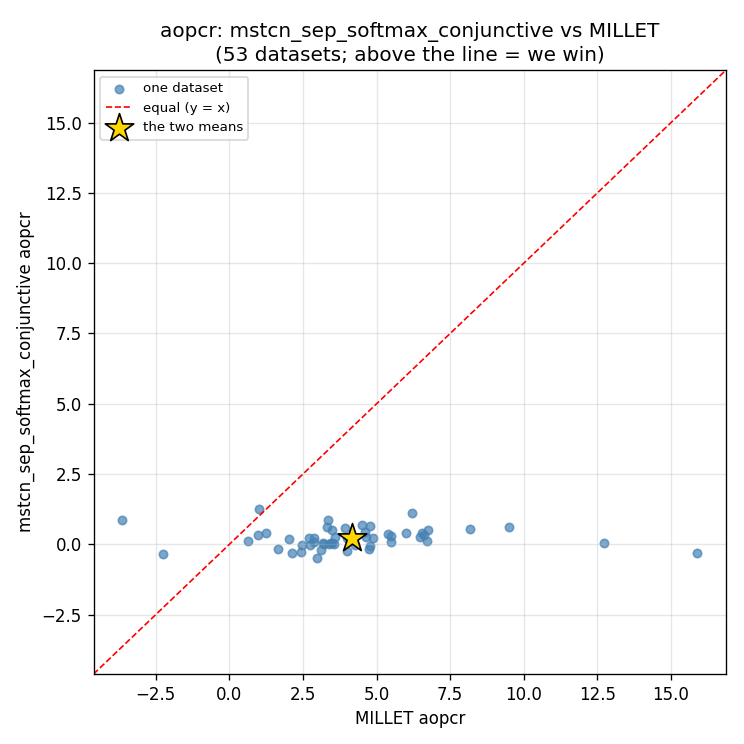

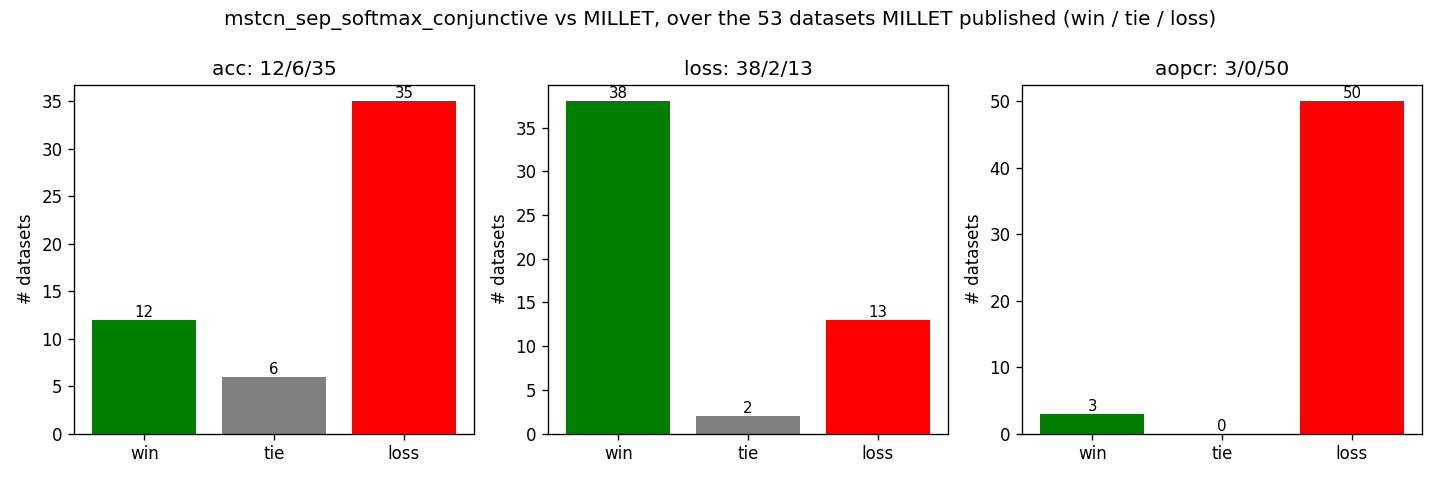

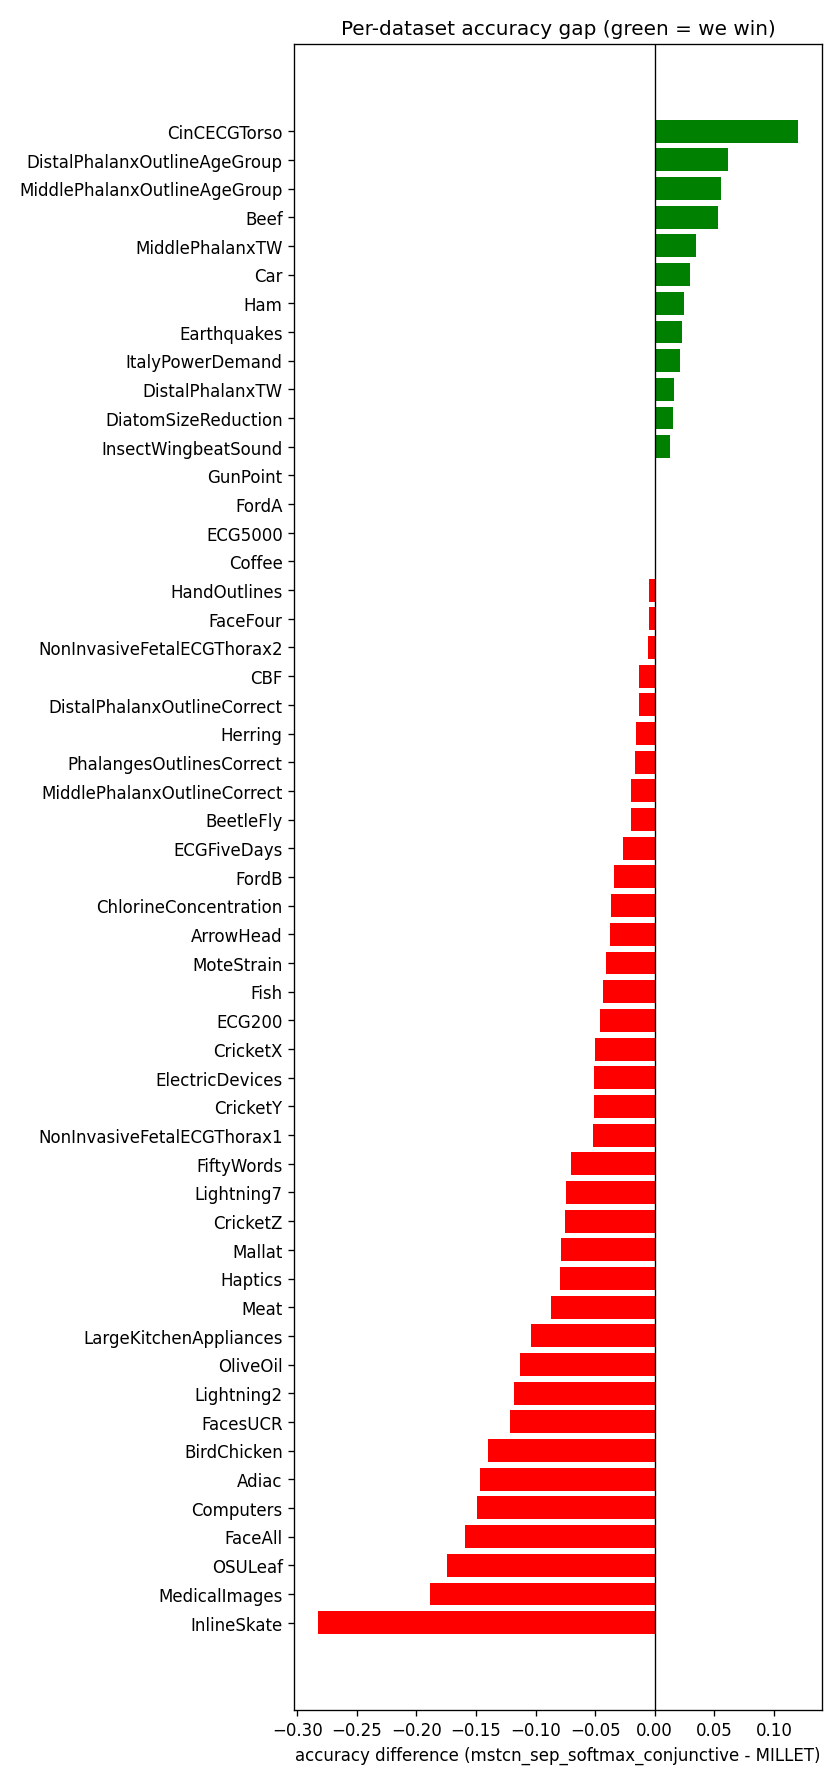

resnet_conjunctive


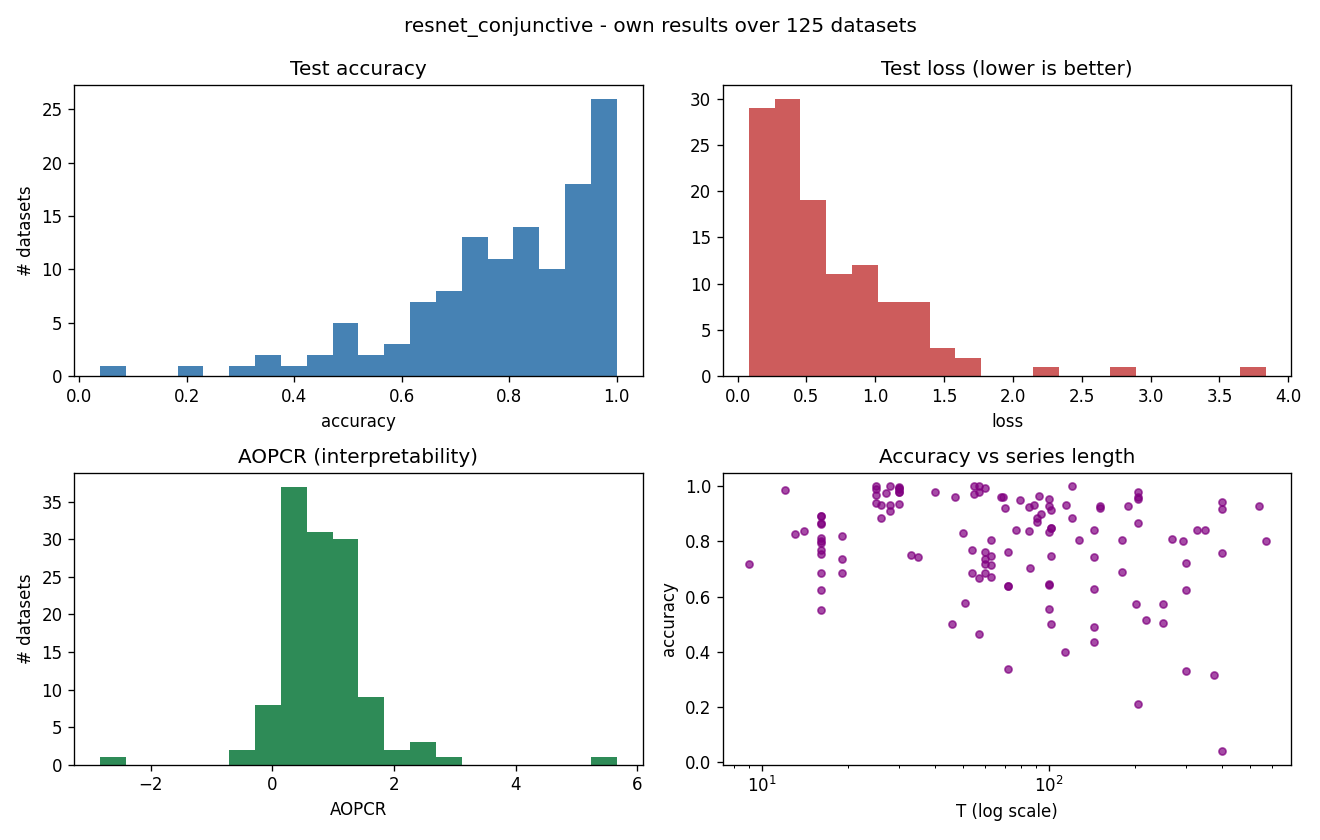

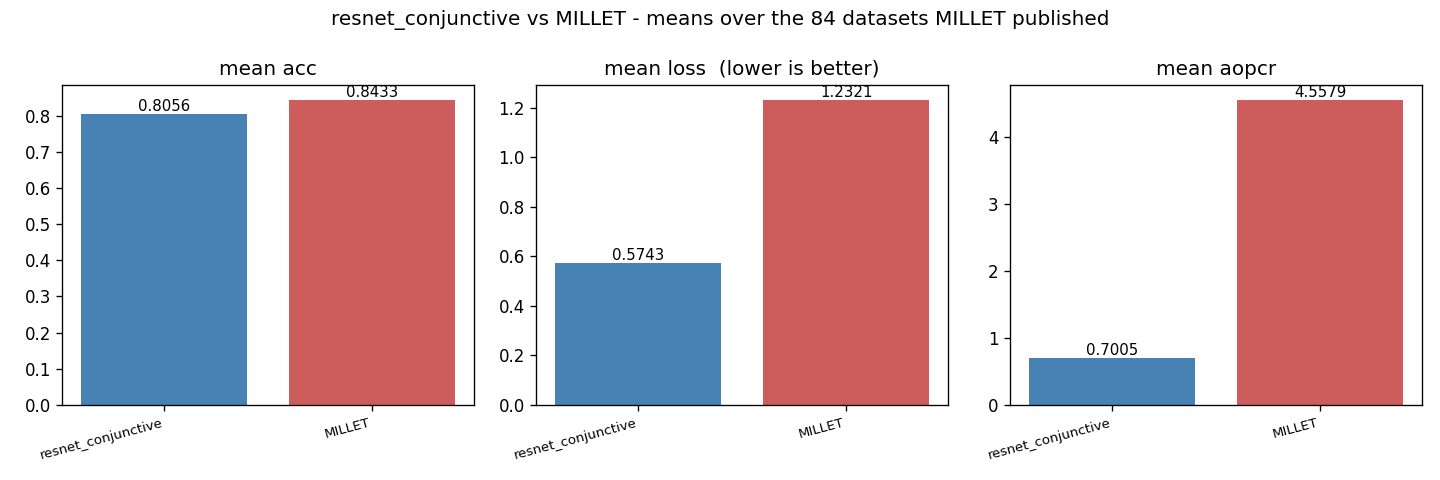

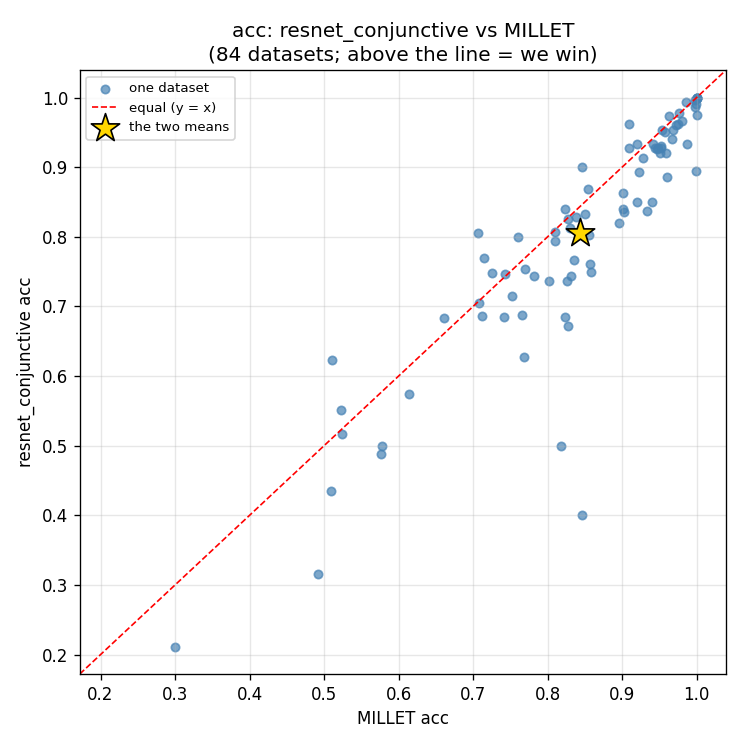

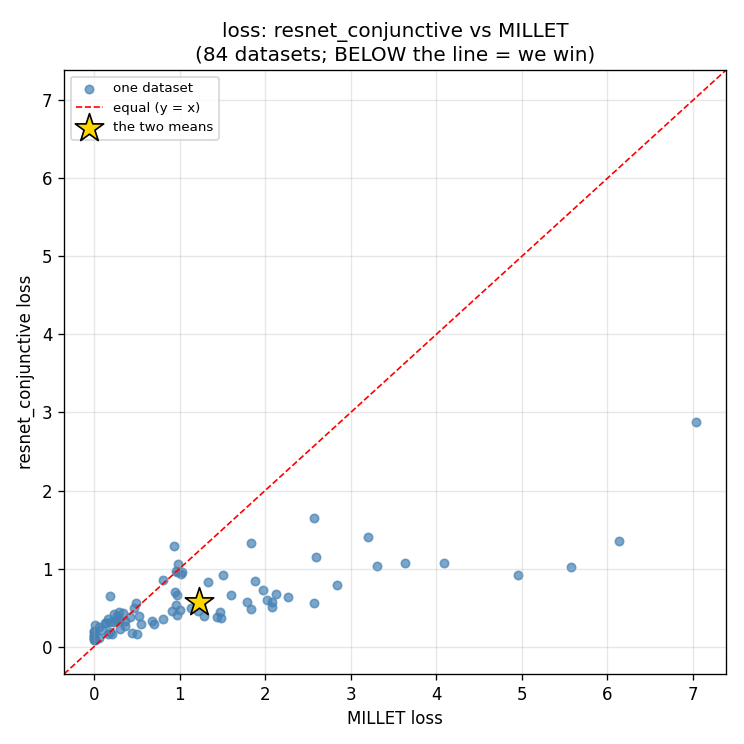

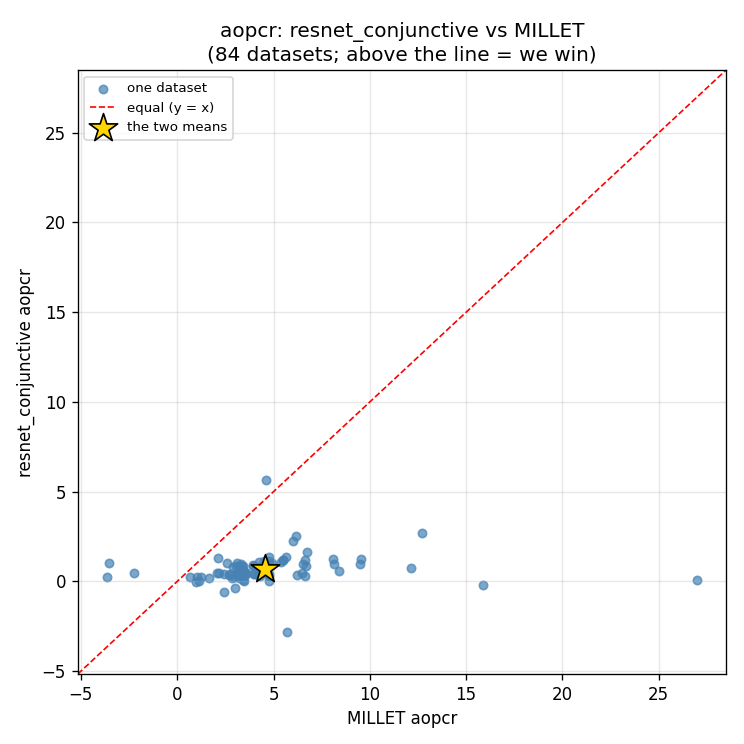

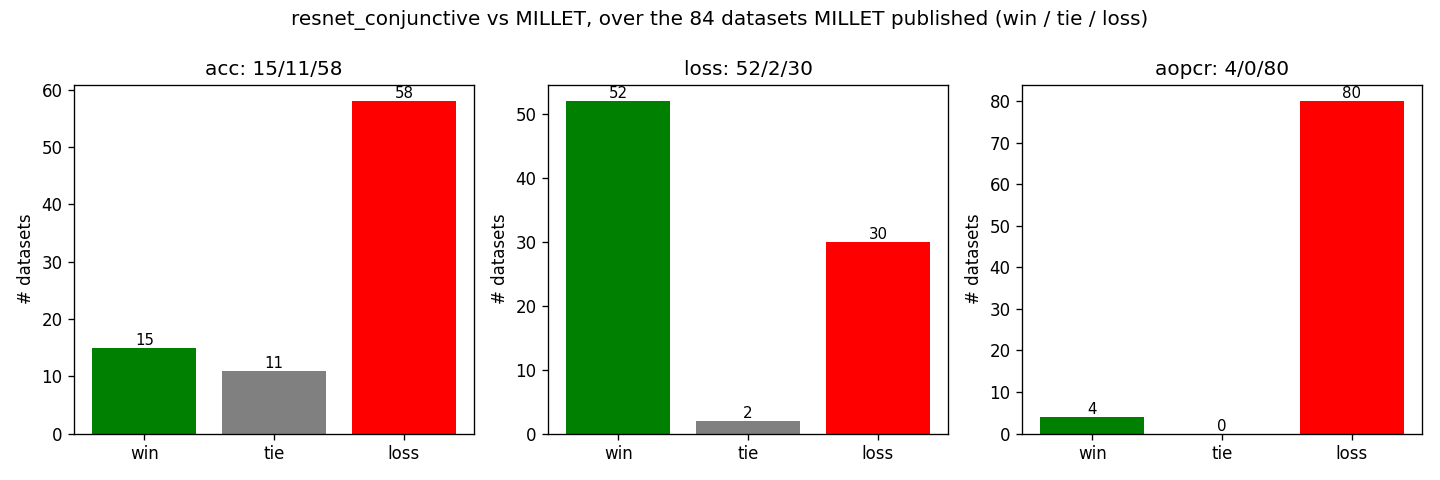

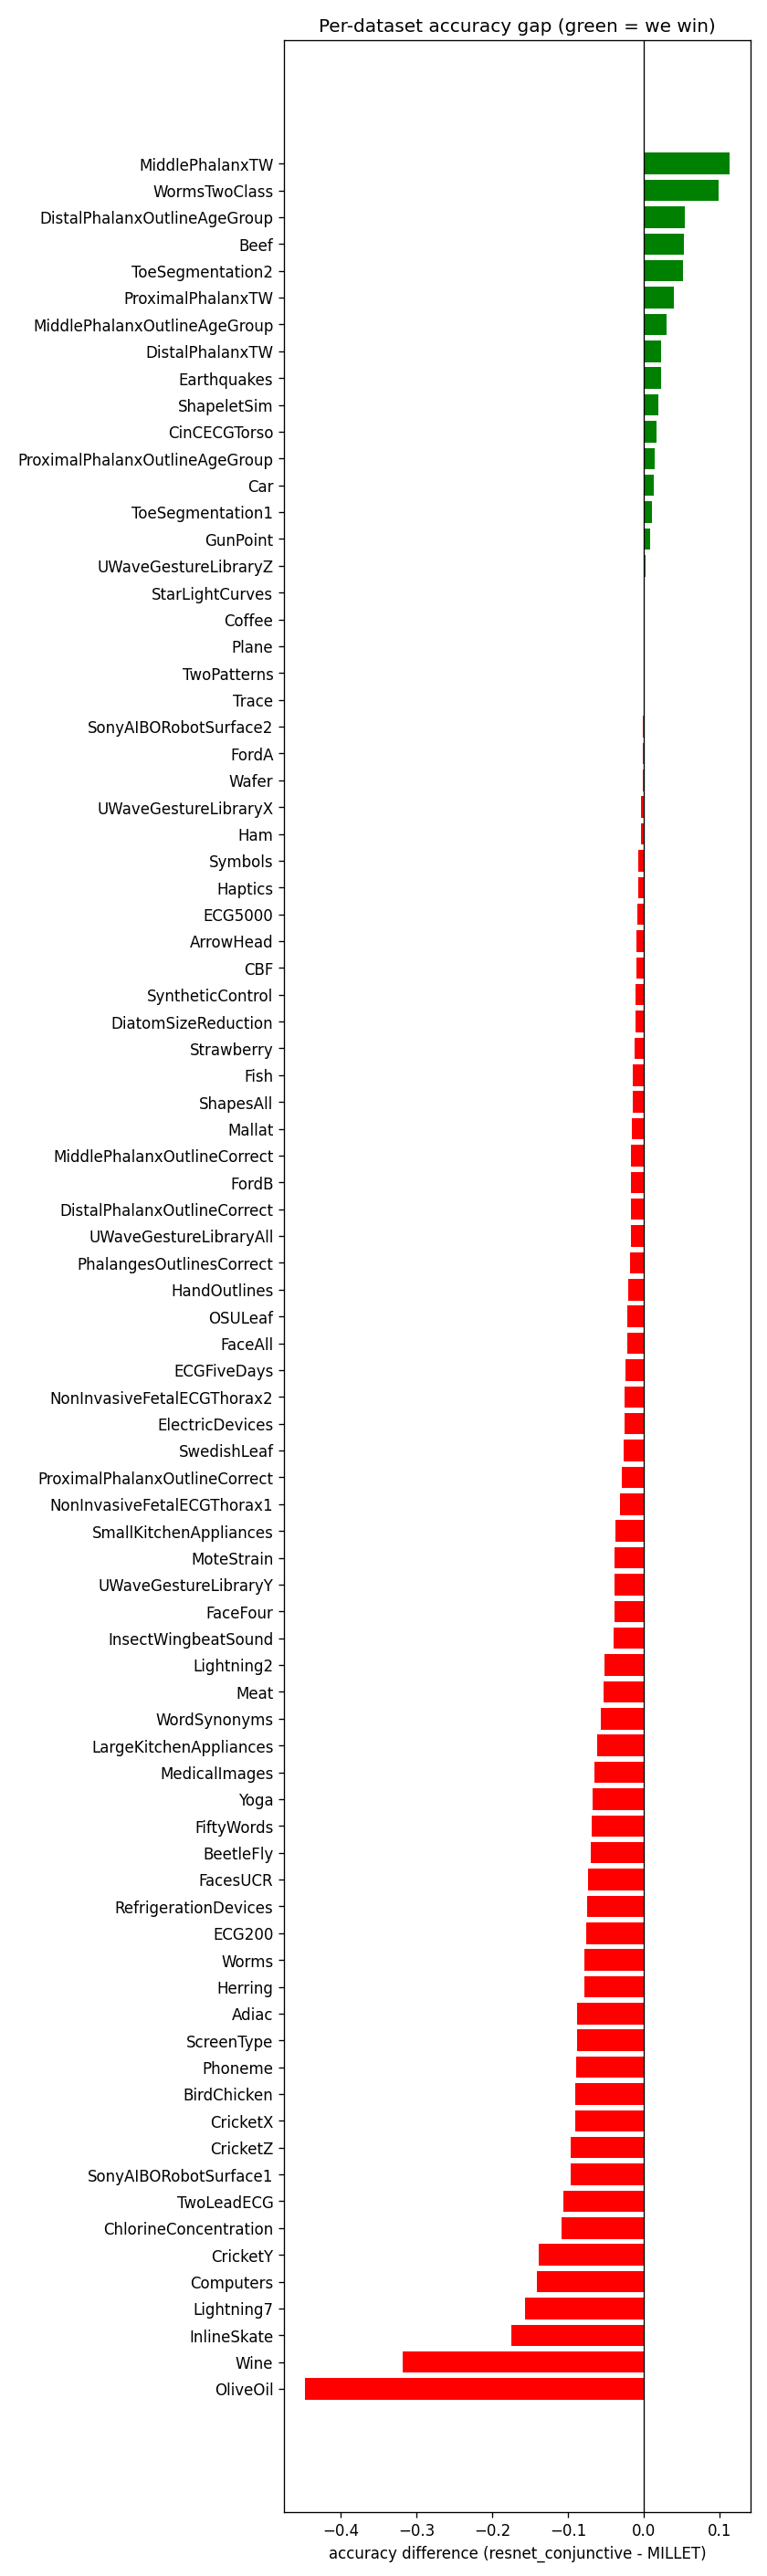

In [4]:
for model_id in R.discover_models():
    print("=" * 70)
    print(model_id)
    print("=" * 70)
    figdir = R.figures_dir(model_id)
    for name in ["results.png", "means.png", "acc_scatter.png", "loss_scatter.png",
                 "aopcr_scatter.png", "win_tie_loss.png", "acc_diff.png"]:
        path = os.path.join(figdir, name)
        if os.path.exists(path):
            display(Image(filename=path))

## 4. The underlying tables

The data behind the figures: one model's per-dataset results, and its comparison to MILLET (only the
85 datasets that overlap the paper have a MILLET number; the other ~43 are marked `no_baseline`).

In [6]:
models = R.discover_models()
if models:
    model_id = models[0]                      # change this to look at a different model
    print("showing:", model_id)

    results = R.load_results(model_id)
    print("datasets with results:", len(results))
    display(results[["dataset", "test_acc", "test_loss", "test_aopcr", "test_ndcg",
                     "train_time_s", "run_datetime"]].head())

    cmp = R.build_comparison(model_id, verbose=False)
    overlap = R.overlap_rows(cmp)
    print(f"datasets with a MILLET baseline: {len(overlap)} of {len(cmp)}")
    display(overlap[["dataset", "ours_acc", "millet_acc", "acc_outcome",
                     "ours_loss", "millet_loss", "loss_outcome",
                     "ours_aopcr", "millet_aopcr", "aopcr_outcome"]].head(10))

    print("headline summary:")
    for key, value in R.summarise_model(model_id).items():
        print(f"  {key:24s}: {value}")
else:
    print("No model has results yet - run: python main.py train --model seanet")

showing: fcn_conjunctive
datasets with results: 125


,dataset,test_acc,test_loss,test_aopcr,test_ndcg,train_time_s,run_datetime
0,WebTraffic,0.5660,1.3026,1.9220,NaN,11.50,2026-07-20 17:03:34
1,Adiac,0.7801,0.8577,-0.0742,NaN,12.22,2026-07-20 17:03:52
2,ArrowHead,0.8286,0.4433,0.4436,NaN,7.32,2026-07-20 17:04:03
3,Beef,0.7667,0.7325,1.4211,NaN,8.92,2026-07-20 17:04:17
4,BeetleFly,0.8500,0.3307,0.7777,NaN,4.52,2026-07-20 17:04:25


datasets with a MILLET baseline: 84 of 124


,dataset,ours_acc,millet_acc,acc_outcome,ours_loss,millet_loss,loss_outcome,ours_aopcr,millet_aopcr,aopcr_outcome
0,Adiac,0.7801,0.8317,loss,0.8577,1.0280,win,-0.0742,15.8906,loss
1,ArrowHead,0.8286,0.8377,loss,0.4433,1.0053,win,0.4436,3.2005,loss
2,Beef,0.7667,0.8467,loss,0.7325,0.9650,win,1.4211,5.4866,loss
3,BeetleFly,0.8500,0.9200,loss,0.3307,0.2905,loss,0.7777,1.2424,loss
4,BirdChicken,1.0000,0.9400,win,0.1831,0.1447,loss,0.7777,3.3665,loss
5,Car,0.9167,0.9200,tie,0.3771,0.4259,win,1.3424,6.6173,loss
6,CBF,0.9933,0.9998,loss,0.1914,0.0007,loss,0.5734,3.5827,loss
7,ChlorineConcentration,0.8276,0.8576,loss,0.4770,0.9747,win,0.7169,2.1418,loss
8,CinCECGTorso,0.8978,0.8239,win,0.3739,0.9547,win,1.6203,4.7745,loss
9,Coffee,1.0000,1.0000,tie,0.0877,0.0000,loss,0.4527,3.4889,loss


headline summary:
  model                   : fcn_conjunctive
  millet85_datasets       : 84
  mean_acc_ours           : 0.8029
  mean_acc_millet         : 0.8433
  acc_win_tie_loss        : 12/17/55
  mean_loss_ours          : 0.5854
  mean_loss_millet        : 1.2321
  loss_win_tie_loss       : 51/1/32
  mean_aopcr_ours         : 0.6864
  mean_aopcr_millet       : 4.5579
  aopcr_win_tie_loss      : 3/0/81
  overall_ucr_datasets    : 124
  overall_mean_acc        : 0.7867
  overall_mean_loss       : 0.6494
  overall_mean_aopcr      : 0.7549
  webtraffic_acc          : 0.566
  params                  : 271131
  model_size_mb           : 3.489


## Notes

- **The fair comparison is the 85 datasets MILLET published.** The `overall_mean_*` numbers cover
  every UCR dataset we trained; MILLET never reported those, so there is nothing to compare them to.
- **Accuracy** vs MILLET: the accuracy scatter, the win/tie/loss bars, and the per-dataset gap.
- **Loss**: lower is better, so in `loss_scatter.png` the winning side is *below* the line.
- **AOPCR** (interpretation faithfulness): the AOPCR scatter. This has been SEA-Net's weak spot -
  it is the main reason the new pooling heads exist.
- **NDCG@n** only exists for WebTraffic (the only dataset with per-timestep ground truth); see each
  model's `summary.csv`.
- To regenerate outside the notebook: `python main.py report`.
- Re-run after more of a sweep finishes to refresh.